<h1 align=center> Projeto ECAC </h1>
<div align=center>
<strong>Trabalho realizado por:</strong><br>
  André Ramos | 2023227306<br>
  Rodrigo Oliveira | 2023231040
</div>

# Introdução

O presente relatório descreve o desenvolvimento e análise de uma pipeline de processamento de dados biométricos no contexto do reconhecimento de atividades humanas. O objetivo principal é compreender e aplicar as etapas fundamentais de uma análise de dados: preparação, limpeza, extração de características e redução/selecção de features. Foram utilizados dados do dataset FORTH-TRACE, que contém medições de sensores inerciais (acelerómetro, giroscópio e magnetómetro) recolhidos de 15 participantes em 16 atividades distintas. O código foi desenvolvido em Python, recorrendo essencialmente às bibliotecas NumPy, SciPy, scikit-learn e matplotlib.

# Meta 1

## Metodologia

O código principal foi implementado no ficheiro 'mainActivity.ipynb', estruturado em funções modulares que permitem realizar cada uma das tarefas solicitadas no enunciado. As principais fases são: (i) carregamento e organização dos dados; (ii) análise e tratamento de outliers; (iii) extração e transformação de características; (iv) redução de dimensionalidade e seleção de features.

In [67]:
# NumPy e arrays
import numpy as np
import pandas as pd
import random

# I/O e Sistema de Ficheiros
import csv
import os

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# Estatística e Sinais
from scipy.stats import kstest, f_oneway, kruskal, wilcoxon, ttest_rel
from scipy.signal import welch

# Machine Learning e Pré-processamento
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, 
    recall_score, f1_score, classification_report
)

# Deep Learning (PyTorch para embeddings)
import torch

# Utilidades
from collections import Counter
import gc

## 2. Carregamento dos dados dos participantes

In [68]:

def load_participant_data(participant_id,
                          data_folder=r'/home/andr-ramos/Downloads/FORTH_TRACE_DATASET-master'):
    participant_folder = os.path.join(data_folder, f'part{participant_id}')
    all_data = []

    # Carregar dados dos 5 dispositivos
    for device_id in range(1, 6):
        filename = f'part{participant_id}dev{device_id}.csv'
        filepath = os.path.join(participant_folder, filename)

        try:
            with open(filepath, 'r') as csvfile:
                csv_reader = csv.reader(csvfile)
                for row in csv_reader:
                    try:
                        data_row = [float(value) for value in row]
                        all_data.append(data_row)
                    except ValueError:
                        continue
        except FileNotFoundError:
            print(f"Aviso: Ficheiro {filename} não encontrado.")
            continue

    data_array = np.array(all_data)
    return data_array

participant_id = 2
data = load_participant_data(participant_id)
print(f" Dados carregados: {data.shape}")
X_accel = X_gyro = X_mag = y_accel = y_gyro = y_mag = None

data_temp = []
datas_list = {participant_id: data}
for i in range(0, 15):
    data_temp = load_participant_data(i)
    datas_list[i] = data_temp



 Dados carregados: (266240, 12)


## 3 Análise e tratamento de outliers

### 3.1 Boxplots por atividade

A função 'plot_boxplot_by_activity' permite visualizar a distribuição dos módulos dos vetores de aceleração, giroscópio ou magnetómetro para cada atividade presente no dataset. A função começa por determinar as colunas correspondentes ao vetor escolhido (x, y e z), calculando de seguida o respetivo módulo através da função auxiliar 'calculate_vector_magnitude'. Depois, extrai o número da atividade de cada amostra e agrupa os valores da magnitude por atividade. Por fim, gera um boxplot onde cada caixa representa a distribuição dos módulos para uma atividade específica. Esta visualização permite identificar diferenças entre atividades, padrões característicos e possíveis outliers nos dados de cada sensor.

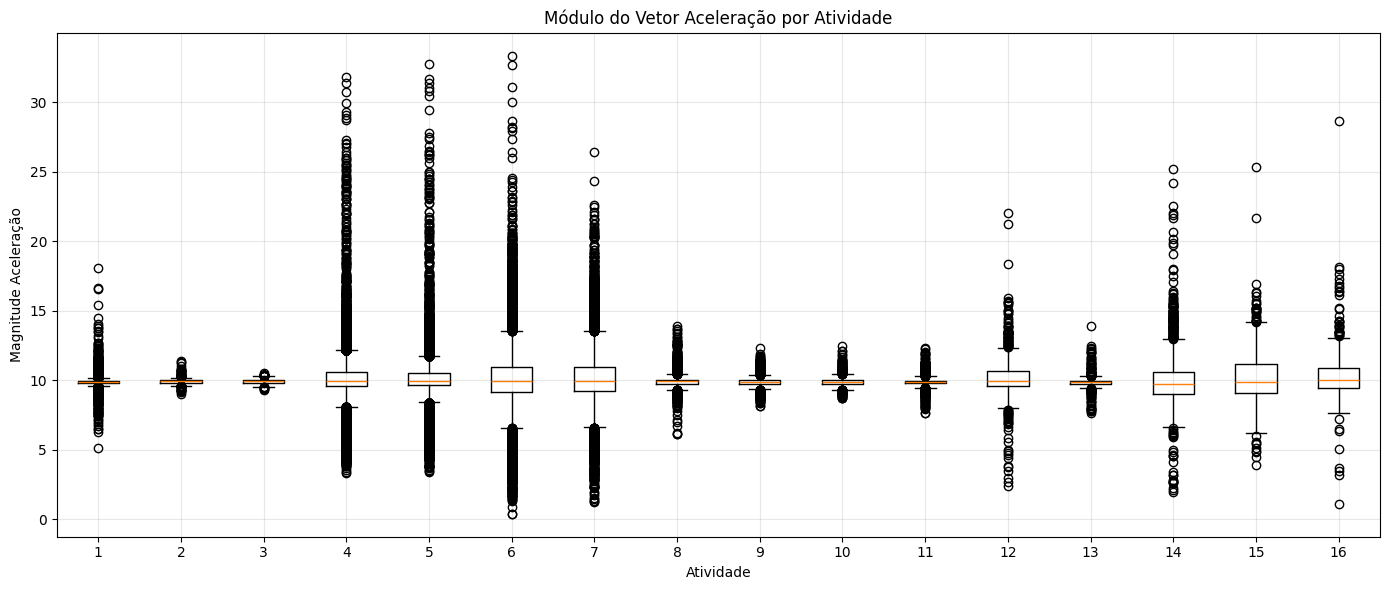

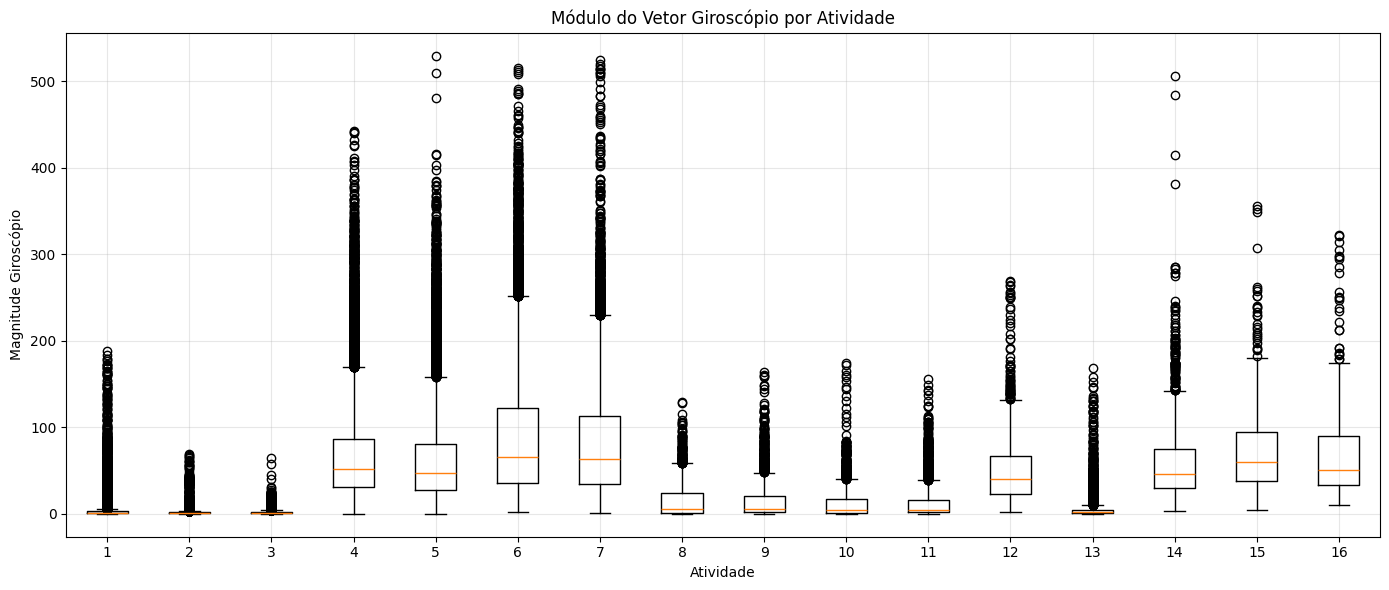

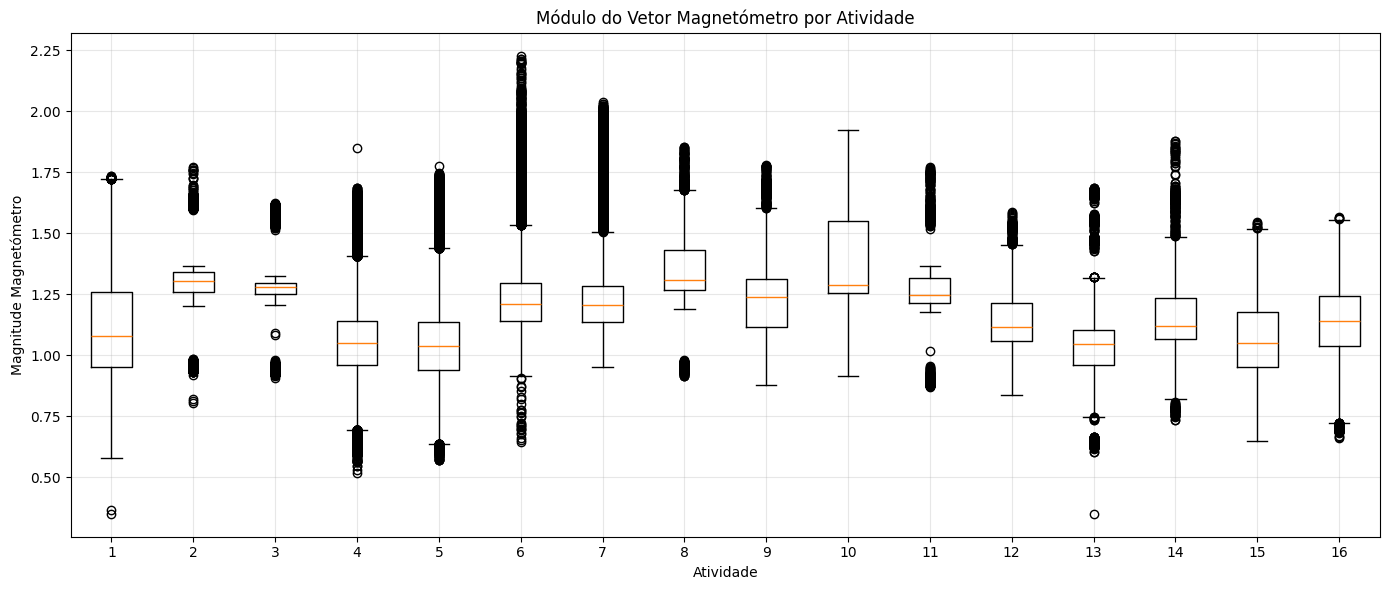

In [69]:

def calculate_vector_magnitude(data_array, start_col):
    x = data_array[:, start_col]
    y = data_array[:, start_col + 1]
    z = data_array[:, start_col + 2]

    magnitude = np.sqrt(x ** 2 + y ** 2 + z ** 2)

    return magnitude

def plot_boxplot_by_activity(data_array, vector_type='accel'):
    # Definir coluna inicial baseada no tipo de vetor
    if vector_type == 'accel':
        start_col = 1
        title = 'Módulo do Vetor Aceleração por Atividade'
        ylabel = 'Magnitude Aceleração'
    elif vector_type == 'gyro':
        start_col = 4
        title = 'Módulo do Vetor Giroscópio por Atividade'
        ylabel = 'Magnitude Giroscópio'
    elif vector_type == 'mag':
        start_col = 7
        title = 'Módulo do Vetor Magnetómetro por Atividade'
        ylabel = 'Magnitude Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Calcular o módulo do vetor
    magnitude = calculate_vector_magnitude(data_array, start_col)

    # Obter as atividades
    activities = data_array[:, 11]

    # Obter atividades únicas e ordenar
    unique_activities = np.sort(np.unique(activities))

    # Preparar dados para o boxplot
    data_by_activity = []
    for activity in unique_activities:
        mask = activities == activity
        data_by_activity.append(magnitude[mask])

    # Criar o boxplot
    plt.figure(figsize=(14, 6))
    plt.boxplot(data_by_activity, tick_labels=unique_activities.astype(int))
    plt.xlabel('Atividade')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show(block=False)

for v in ['accel', 'gyro', 'mag']:
    plot_boxplot_by_activity( data, vector_type=v)

### 3.2 Densidade de outliers (IQR – Tukey)

A função 'calcular_densidade_outliers' tem como objetivo determinar a densidade de outliers presentes nos módulos dos vetores de aceleração, giroscópio ou magnetómetro, utilizando o método IQR (Tukey). Para garantir consistência com o enunciado, a análise é realizada apenas para o dispositivo do pulso direito (Device ID = 2). Após selecionar as colunas correspondentes ao vetor escolhido, calcula-se o módulo através da função auxiliar 'calculate_vector_magnitude'. Em seguida, para cada atividade, o algoritmo aplica o critério IQR para identificar valores considerados outliers e calcula a sua densidade relativa, definida como a razão entre o número de outliers e o número total de amostras da atividade. Por fim, a função apresenta as densidades por atividade e devolve-as num dicionário. Esta análise permite quantificar a presença de valores extremos e avaliar a qualidade dos dados recolhidos para cada tipo de sensor.

In [70]:
def calcular_densidade_outliers(data_array, vector_type='accel', k=3):

    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Escolher o dispositivo (pulso direito)
    mask_device = data_array[:, 0] == 2
    data_filtered = data_array[mask_device]

    magnitude = calculate_vector_magnitude(data_filtered, start_col)
    activities = data_filtered[:, 11]
    unique_activities = np.sort(np.unique(activities))

    densidades = {}
    for activity in unique_activities:
        mask = activities == activity
        dados_atividade = magnitude[mask]

        # --- Método IQR (Tukey) ---
        Q1 = np.percentile(dados_atividade, 25)
        Q3 = np.percentile(dados_atividade, 75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = dados_atividade[(dados_atividade < lower_bound) | (dados_atividade > upper_bound)]

        no = len(outliers)
        nr = len(dados_atividade)
        densidade = (no / nr) * 100 if nr > 0 else 0
        densidades[int(activity)] = densidade

    print(f"\nDensidades de outliers ({vector_type},):")
    for a, d in densidades.items():
        print(f"  Atividade {a}: {d:.2f}%")

    return densidades


for v in ['accel', 'gyro', 'mag']:
    calcular_densidade_outliers (data, vector_type=v, k=3)


Densidades de outliers (accel,):
  Atividade 1: 3.43%
  Atividade 2: 3.98%
  Atividade 3: 4.05%
  Atividade 4: 1.68%
  Atividade 5: 2.36%
  Atividade 6: 4.47%
  Atividade 7: 2.41%
  Atividade 8: 24.61%
  Atividade 9: 23.70%
  Atividade 10: 24.22%
  Atividade 11: 18.49%
  Atividade 12: 3.15%
  Atividade 13: 0.79%
  Atividade 14: 11.02%
  Atividade 15: 2.36%
  Atividade 16: 1.57%

Densidades de outliers (gyro,):
  Atividade 1: 6.82%
  Atividade 2: 5.34%
  Atividade 3: 8.59%
  Atividade 4: 1.85%
  Atividade 5: 1.46%
  Atividade 6: 1.20%
  Atividade 7: 3.12%
  Atividade 8: 3.52%
  Atividade 9: 2.08%
  Atividade 10: 7.62%
  Atividade 11: 11.20%
  Atividade 12: 3.54%
  Atividade 13: 1.18%
  Atividade 14: 8.66%
  Atividade 15: 10.24%
  Atividade 16: 12.60%

Densidades de outliers (mag,):
  Atividade 1: 0.00%
  Atividade 2: 2.11%
  Atividade 3: 0.05%
  Atividade 4: 0.14%
  Atividade 5: 0.00%
  Atividade 6: 0.00%
  Atividade 7: 0.00%
  Atividade 8: 4.88%
  Atividade 9: 13.02%
  Atividade 10: 1

### 3.3 Deteção de outliers por Z-score

Foi implementada a função 'detectar_outliers_zscore', que identifica valores fora de um intervalo definido pela média ± k vezes o desvio padrão. O parâmetro k é ajustável, sendo usados os valores 3, 3.5 e 4. Primeiro os dados são convertidos para um array NumPy, e depois são calculados a média e o desvio padrão, dois valores da formula do Z-score. Se o desvio padrão for igual a 0, o cálculo do Z-score torna-se impossível (divisão por zero). 
O Z-score é útil para dados com distribuição aproximadamente normal, permitindo identificar pontos muito afastados da média.


In [71]:
def detectar_outliers_zscore(dados, k=3):
    # Converter para array NumPy
    dados = np.array(dados)

    # Calcular média e desvio padrão
    media = np.mean(dados)
    desvio = np.std(dados)

    # Evitar divisão por zero
    if desvio == 0:
        return np.array([]), np.array([])

    # Calcular Z-scores
    z_scores = (dados - media) / desvio

    # Identificar outliers
    mask_outliers = np.abs(z_scores) > k

    return dados[mask_outliers], np.where(mask_outliers)[0]



### 3.4 Visualização de outliers (Z-score)

A função 'plot_outliers_zscore' permite identificar e visualizar outliers nos módulos dos vetores de aceleração, giroscópio ou magnetómetro utilizando o método do Z-score. Para cada tipo de vetor, a função calcula primeiro o seu módulo recorrendo à função 'calculate_vector_magnitude' e separa os valores por atividade. Em seguida, para cada atividade, calcula a média e o desvio padrão, obtendo o Z-score de cada amostra. Os pontos cujo valor absoluto do Z-score excede o limiar k são assinalados como outliers.

A função gera gráficos de dispersão para diferentes valores de k (por exemplo, 3, 3.5 e 4), onde cada atividade é representada no eixo horizontal, com um pequeno jitter aplicado para evitar sobreposição dos pontos. As amostras normais são apresentadas a azul e os outliers a vermelho, permitindo uma inspeção clara da distribuição e da presença de valores extremos em cada atividade. Esta visualização complementa a análise estatística, facilitando a comparação entre sensores e a avaliação do impacto da variação do parâmetro k.

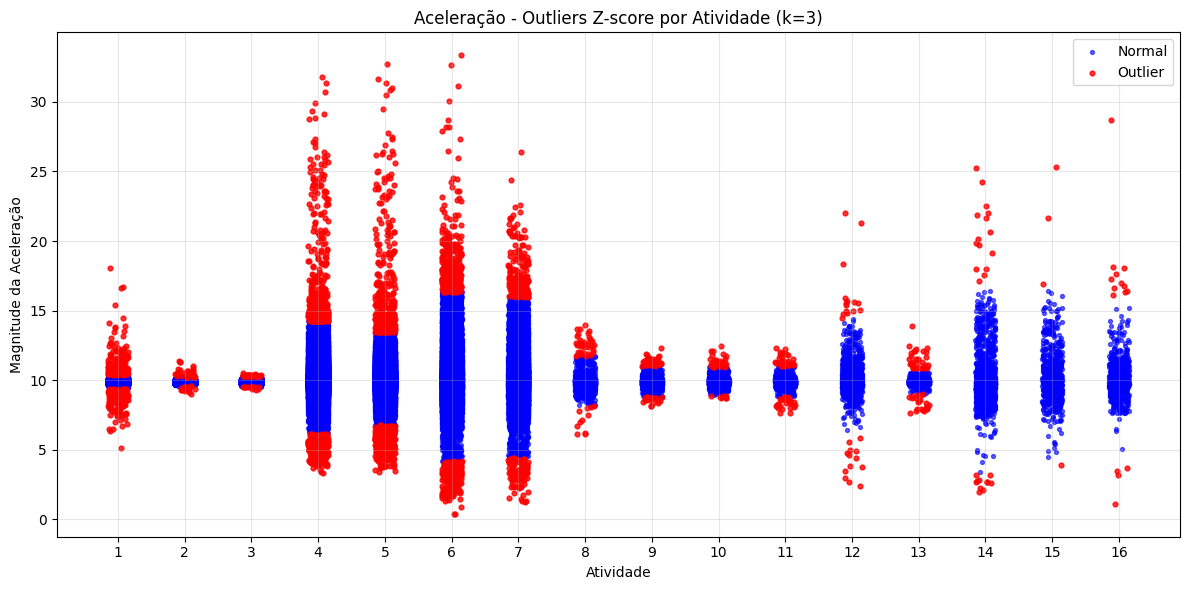

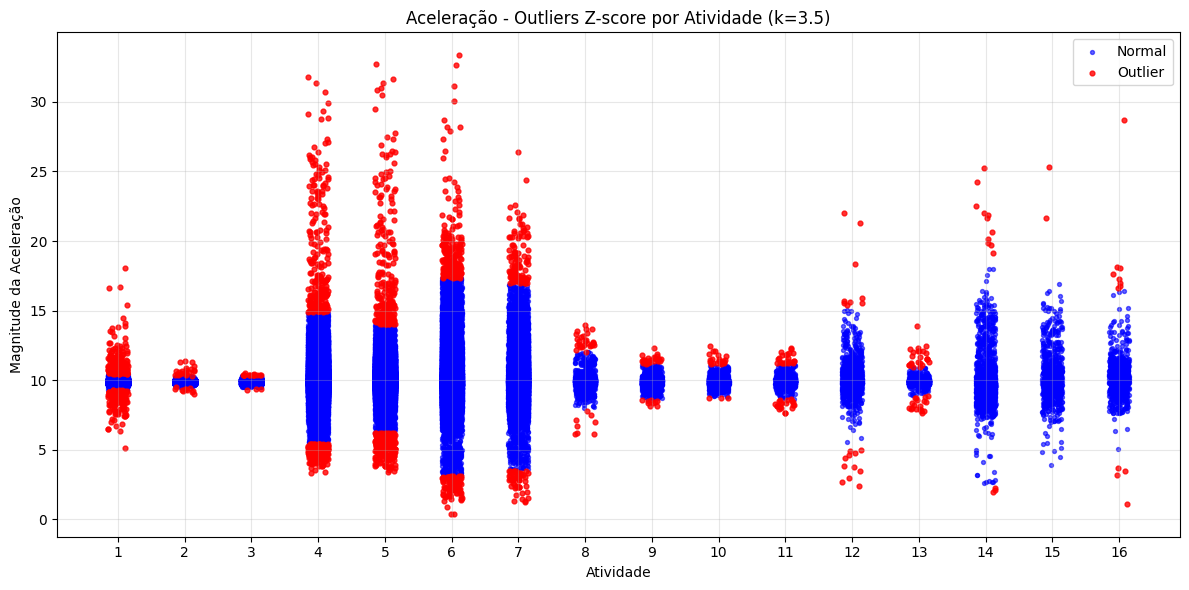

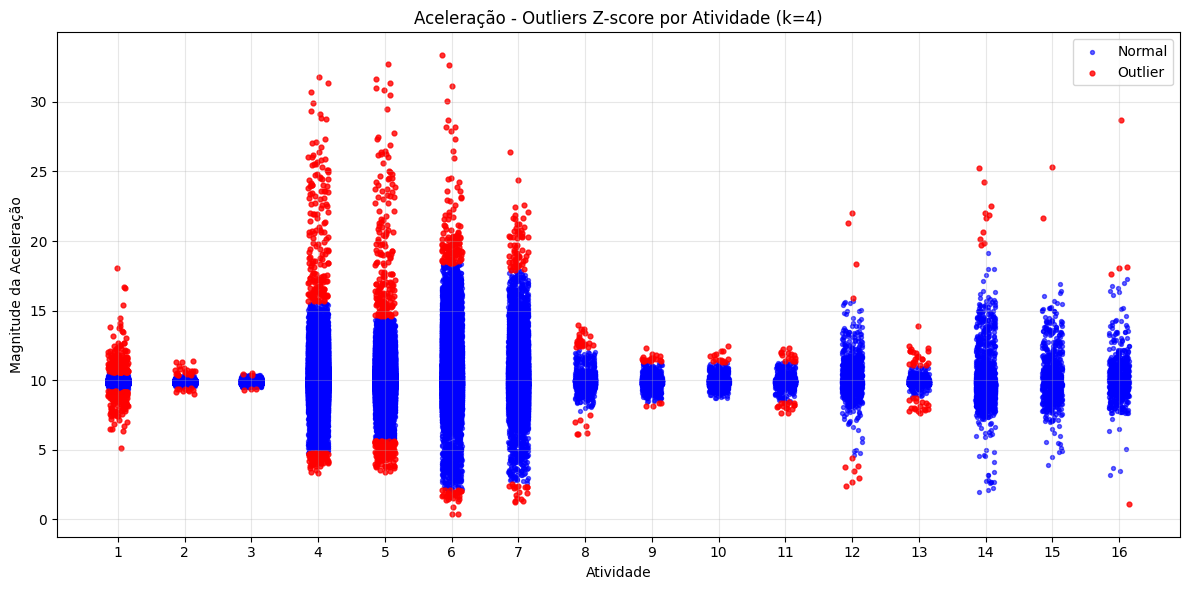

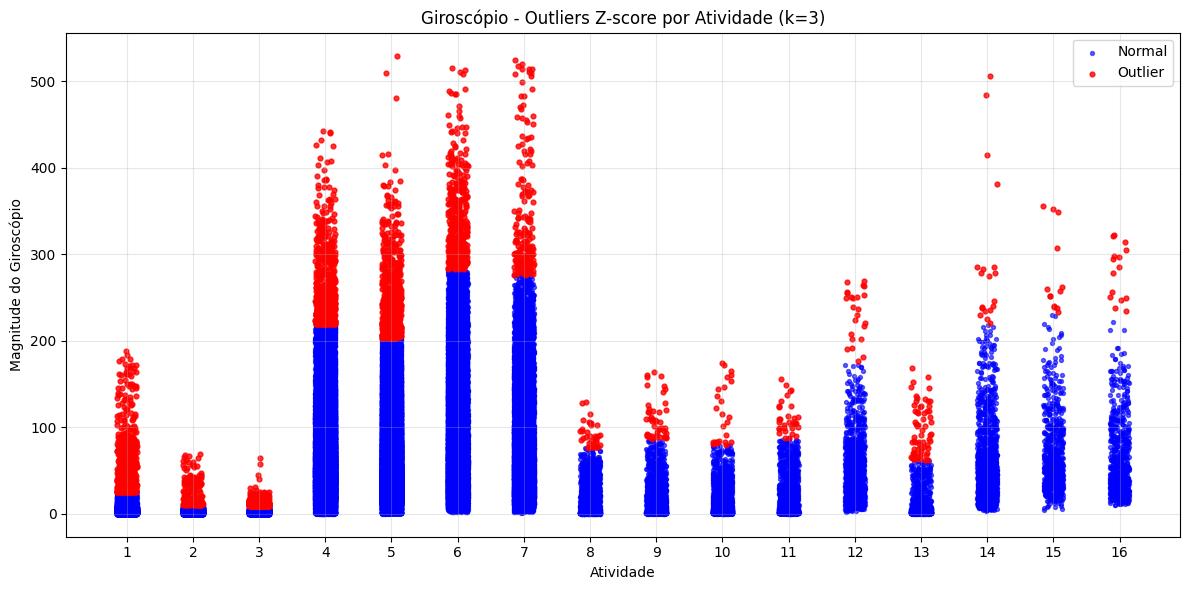

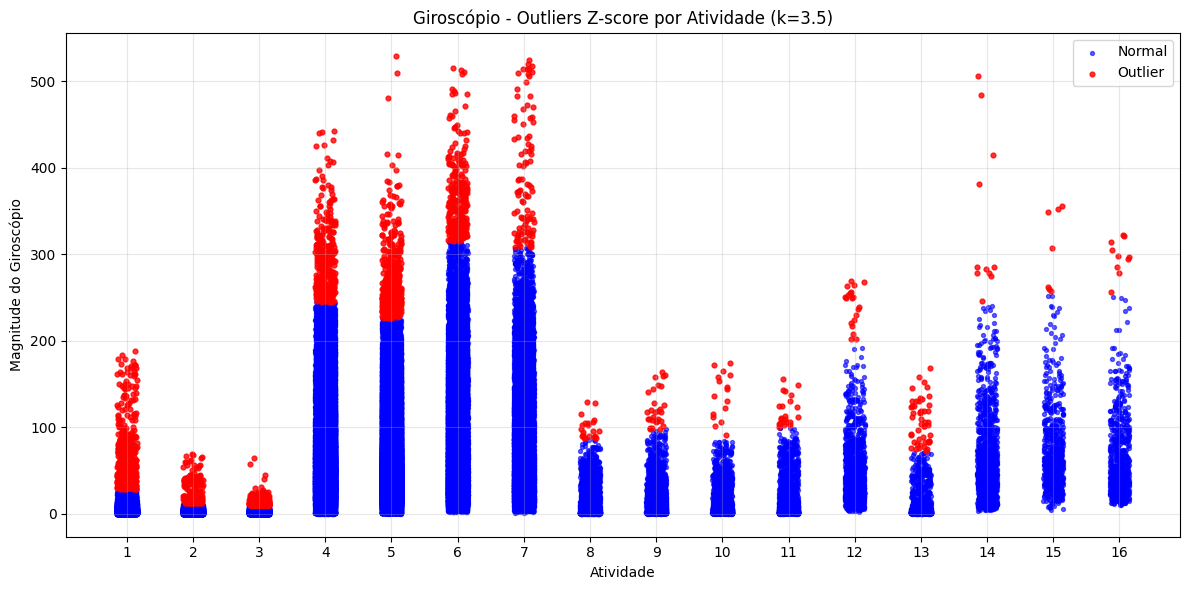

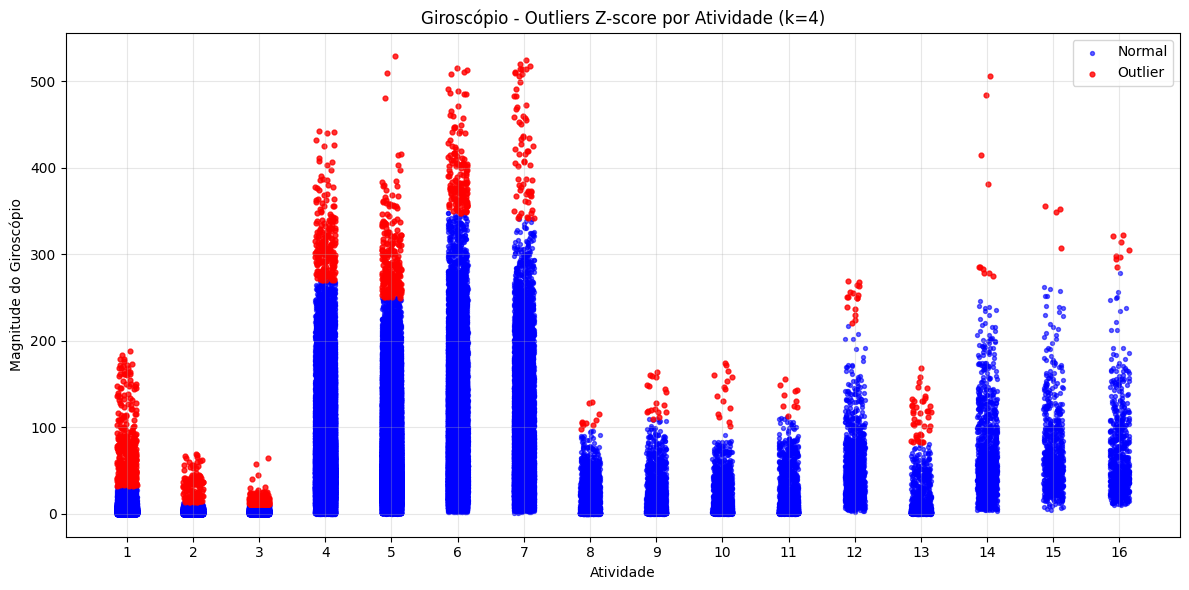

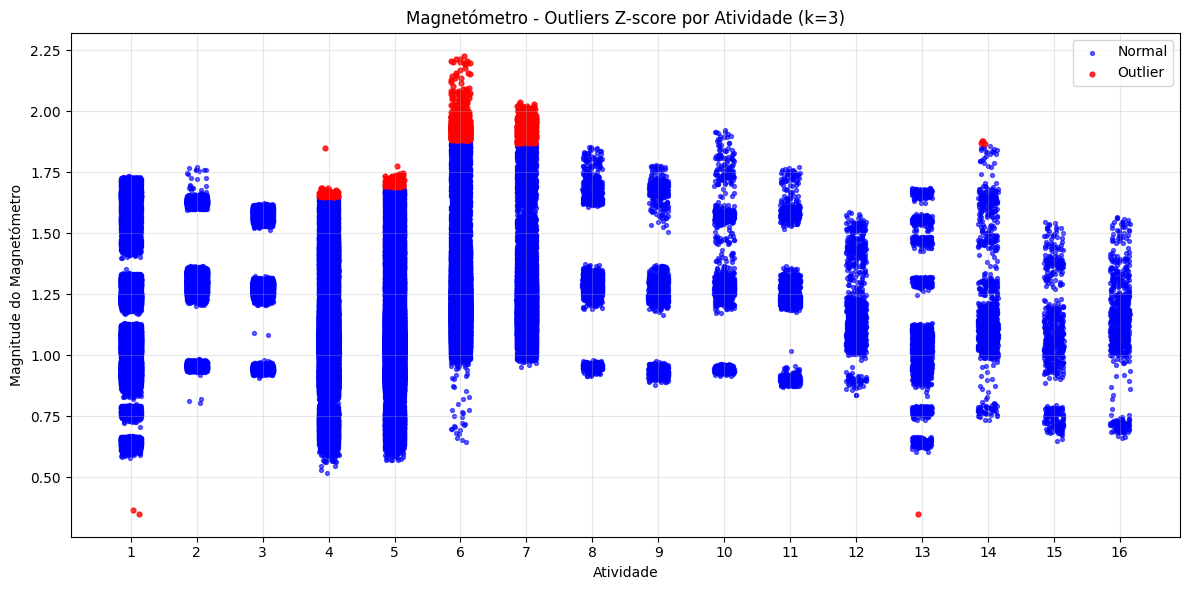

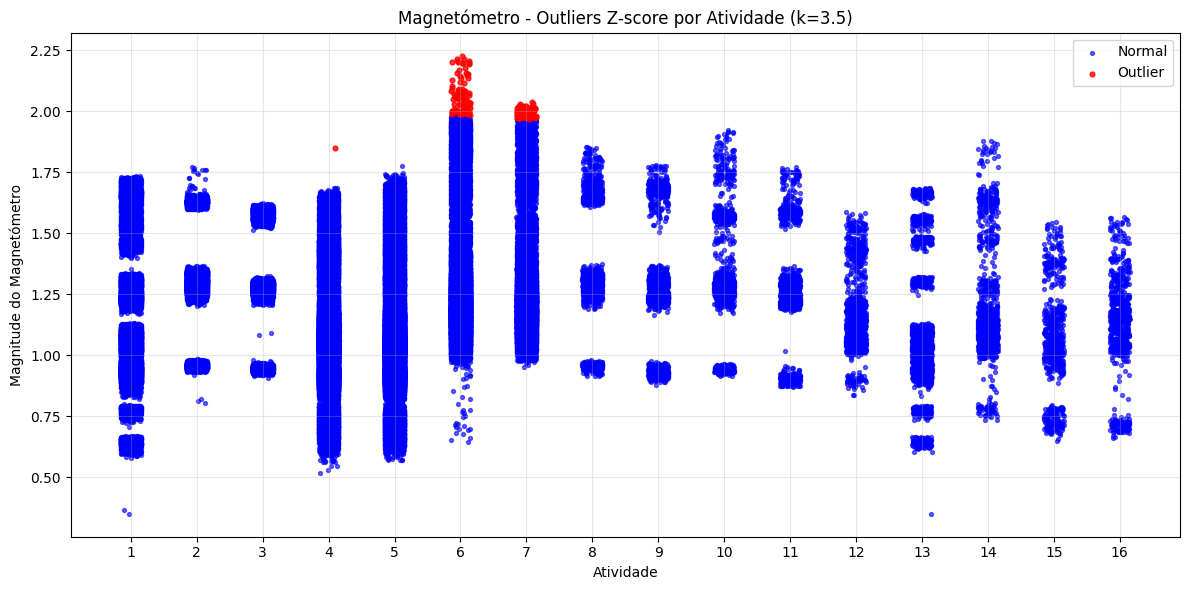

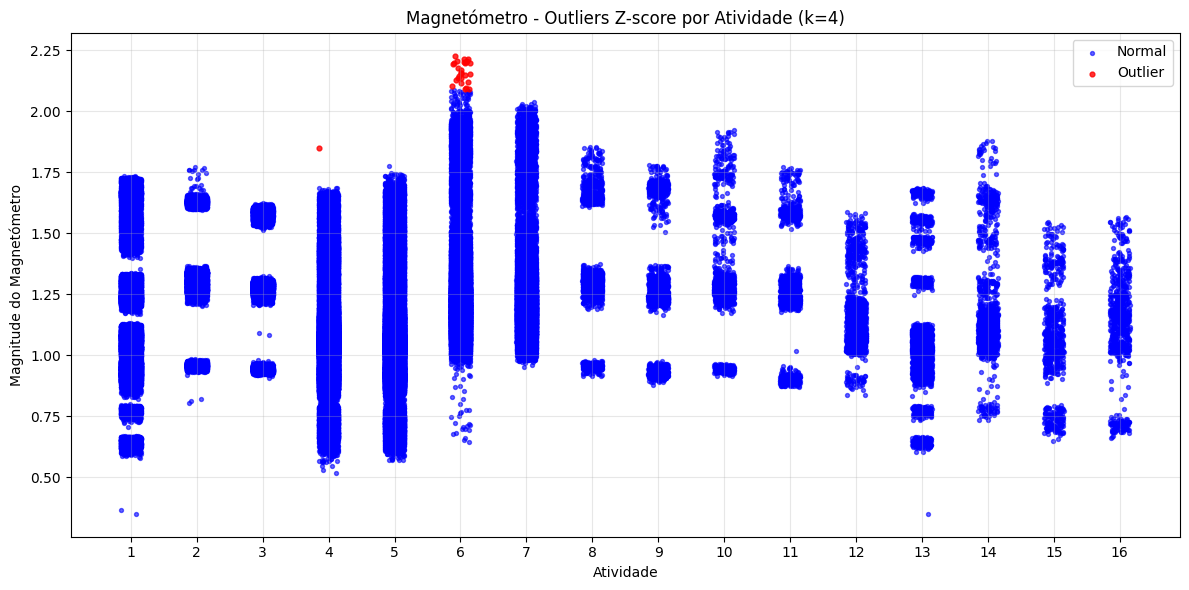

In [72]:
def plot_outliers_zscore(data_array, vector_type='accel', k_values=[3]):

    # Definir coluna inicial e rótulos
    if vector_type == 'accel':
        start_col = 1
        title_base = 'Aceleração'
        ylabel = 'Magnitude da Aceleração'
    elif vector_type == 'gyro':
        start_col = 4
        title_base = 'Giroscópio'
        ylabel = 'Magnitude do Giroscópio'
    elif vector_type == 'mag':
        start_col = 7
        title_base = 'Magnetómetro'
        ylabel = 'Magnitude do Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Calcular magnitude do vetor
    magnitude = calculate_vector_magnitude(data_array, start_col)
    activities = data_array[:, 11]
    unique_activities = np.sort(np.unique(activities))

    # Criar um gráfico para cada valor de k
    for k in k_values:
        plt.figure(figsize=(12, 6))

        for idx, activity in enumerate(unique_activities):
            mask = activities == activity
            dados_atividade = magnitude[mask]

            # Calcular Z-score por atividade
            media = np.mean(dados_atividade)
            desvio = np.std(dados_atividade)
            if desvio == 0:
                z_scores = np.zeros_like(dados_atividade)
            else:
                z_scores = (dados_atividade - media) / desvio

            # Detectar outliers
            mask_outliers = np.abs(z_scores) > k

            # Adicionar leve jitter no eixo X para visualização
            jitter = np.random.uniform(-0.15, 0.15, size=len(dados_atividade))
            x_vals = np.full_like(dados_atividade, fill_value=activity, dtype=float) + jitter

            # Plotar pontos normais e outliers
            plt.scatter(x_vals[~mask_outliers], dados_atividade[~mask_outliers],
                        color='blue', s=8, alpha=0.6, label='Normal' if idx == 0 else "")
            plt.scatter(x_vals[mask_outliers], dados_atividade[mask_outliers],
                        color='red', s=12, alpha=0.8, label='Outlier' if idx == 0 else "")

        plt.title(f"{title_base} - Outliers Z-score por Atividade (k={k})")
        plt.xlabel("Atividade")
        plt.ylabel(ylabel)
        plt.xticks(unique_activities.astype(int))
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show(block=False)


for v in ['accel', 'gyro', 'mag']:
    plot_outliers_zscore (data, vector_type=v, k_values=[3, 3.5, 4])



### 3.5 Comparação entre IQR vs Z-score

A comparação entre o método IQR e o Z-score revela diferenças importantes na deteção de outliers. O método IQR é não paramétrico e baseia-se nos quartis, sendo mais robusto a distribuições assimétricas. Como consequência, tende a identificar menos outliers, funcionando de forma mais conservadora.

Já o Z-score depende da média e do desvio padrão, assumindo implicitamente que os dados têm uma distribuição aproximadamente normal. Por isso, é mais sensível e geralmente deteta um maior número de outliers, sobretudo em atividades com maior variabilidade, como caminhar ou subir escadas.

No geral, o IQR fornece uma deteção mais estável e robusta, enquanto o Z-score destaca melhor desvios significativos. Usados em conjunto, oferecem uma visão complementar sobre a presença de valores extremos no dataset.

### 3.6 Implementação do algoritmo K-means

Foi implementado o algoritmo k-means para explorar a estrutura dos dados dos sensores de aceleração, giroscópio e magnetómetro. O método consiste em inicializar centróides aleatoriamente, atribuir cada ponto ao centróide mais próximo e atualizar os centróides até convergirem. Para determinar o número adequado de clusters, utilizou-se o método do cotovelo, que calcula a soma das distâncias intra-cluster para diferentes valores de k, permitindo identificar visualmente o ponto em que adicionar mais clusters deixa de trazer melhorias significativas. Esta análise permite compreender melhor a distribuição dos dados, identificar agrupamentos naturais e complementar os métodos de deteção de outliers utilizados nas etapas anteriores.

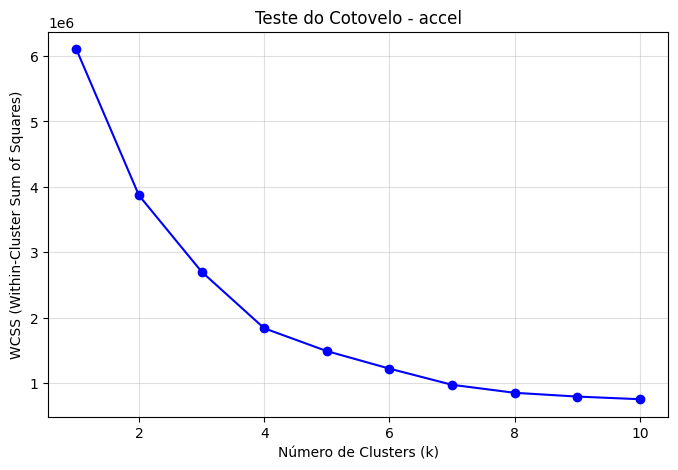

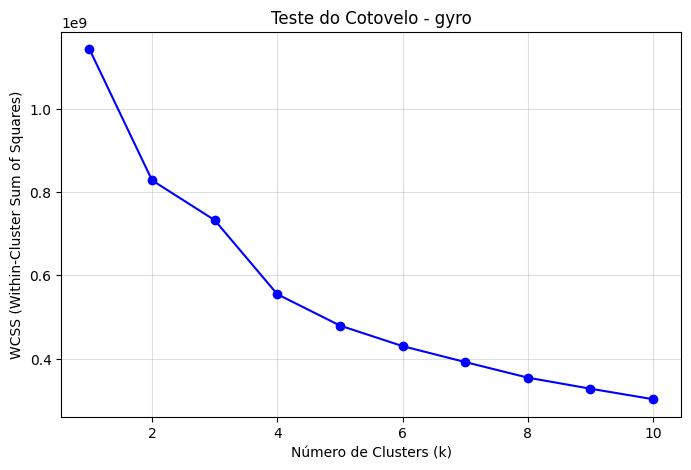

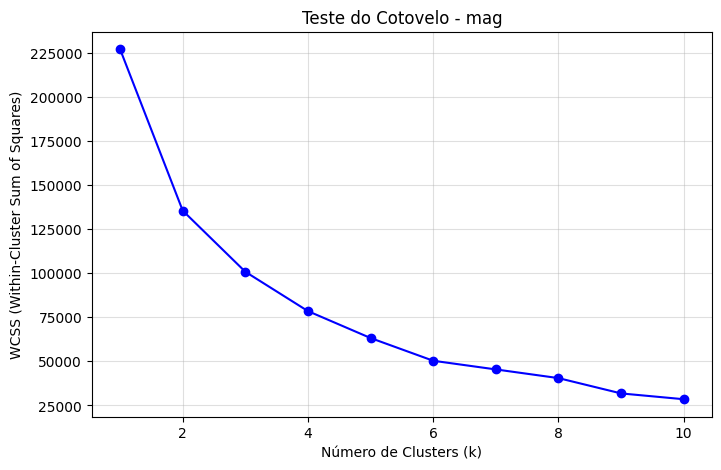


  A executar K-means para accel...
 - K=2: 2 centróides calculados.
 - K=2: 2 centróides calculados.
 - K=3: 3 centróides calculados.
 - K=3: 3 centróides calculados.
 - K=4: 4 centróides calculados.
 - K=4: 4 centróides calculados.
 - K=5: 5 centróides calculados.
 - K=5: 5 centróides calculados.
 - K=6: 6 centróides calculados.
 - K=6: 6 centróides calculados.
 - K=7: 7 centróides calculados.
 - K=7: 7 centróides calculados.
 - K=8: 8 centróides calculados.

  A executar K-means para gyro...
 - K=8: 8 centróides calculados.

  A executar K-means para gyro...
 - K=2: 2 centróides calculados.
 - K=2: 2 centróides calculados.
 - K=3: 3 centróides calculados.
 - K=3: 3 centróides calculados.
 - K=4: 4 centróides calculados.
 - K=4: 4 centróides calculados.
 - K=5: 5 centróides calculados.
 - K=5: 5 centróides calculados.
 - K=6: 6 centróides calculados.
 - K=6: 6 centróides calculados.
 - K=7: 7 centróides calculados.
 - K=7: 7 centróides calculados.
 - K=8: 8 centróides calculados.

  

In [73]:

def k_means(data, n_clusters, max_iters=100, tol=1e-3, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)

    n_samples = data.shape[0]

    # Inicializar centróides aleatoriamente
    indices = np.random.choice(n_samples, n_clusters, replace=False)
    centroids = data[indices].copy()

    for iteration in range(max_iters):
        # Calcular distâncias (vectorizado)
        distances = np.linalg.norm(data[:, np.newaxis, :] - centroids[np.newaxis, :, :], axis=2)
        labels = np.argmin(distances, axis=1)

        # Recalcular centróides
        centroids_old = centroids.copy()
        for k in range(n_clusters):
            cluster_points = data[labels == k]
            if len(cluster_points) > 0:
                centroids[k] = np.mean(cluster_points, axis=0)
            else:
                centroids[k] = data[np.random.choice(n_samples)]

        # Verificar convergência
        if np.linalg.norm(centroids - centroids_old) < tol:
            break

    return labels, centroids

def elbow_method(data_array, vector_type='accel', max_k=10):

    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    data_3d = data_array[:, start_col:start_col + 3]
    wcss = []

    for k in range(1, max_k + 1):
        labels, centroids = k_means(data_3d, k, random_state=42)
        distances = np.linalg.norm(data_3d - centroids[labels], axis=1)
        wcss.append(np.sum(distances ** 2))

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k + 1), wcss, 'bo-', markersize=6)
    plt.xlabel('Número de Clusters (k)')
    plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
    plt.title(f'Teste do Cotovelo - {vector_type}')
    plt.grid(True, alpha=0.4)
    plt.show(block=False)

    return wcss

for v in ['accel', 'gyro', 'mag']:
    elbow_method (data, vector_type=v, max_k=10)
    
for v in ['accel', 'gyro', 'mag']:
    print(f"\n  A executar K-means para {v}...")
    data_3d = data[:, {'accel': 1, 'gyro': 4, 'mag': 7}[v]:{'accel': 1, 'gyro': 4, 'mag': 7}[v] + 3]
    for n_clusters in [2, 3, 4, 5, 6, 7, 8]:
        _, centroids = k_means(data_3d, n_clusters, random_state=42)
        print(f" - K={n_clusters}: {len(centroids)} centróides calculados.")
print(" Execução do 3.6 concluída!")

### 3.7 Deteção de outliers com K-means

A função 'detectar_outliers_kmeans' aplica o K-means no espaço tridimensional (x, y, z) para aceleração, giroscópio e magnetómetro. Os pontos pertencentes aos clusters com menos de 3% dos dados são considerados outliers. A densidade de outliers é calculada e os resultados mostram coerência com os métodos anteriores. Foi também criada a função 'plot_outliers_kmeans_3d' para visualização 3D (não usada neste relatório textual).
Além disso, a função 'comparar_kmeans_vs_zscore' compara quantitativamente os resultados dos dois métodos, mostrando o número de outliers detetados por cada abordagem e o grau de concordância entre ambos, sendo que apenas no giroscópio existe alguma concordância.



K-means com 3 clusters (accel):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(26718), np.int64(1): np.int64(83815), np.int64(2): np.int64(155707)}


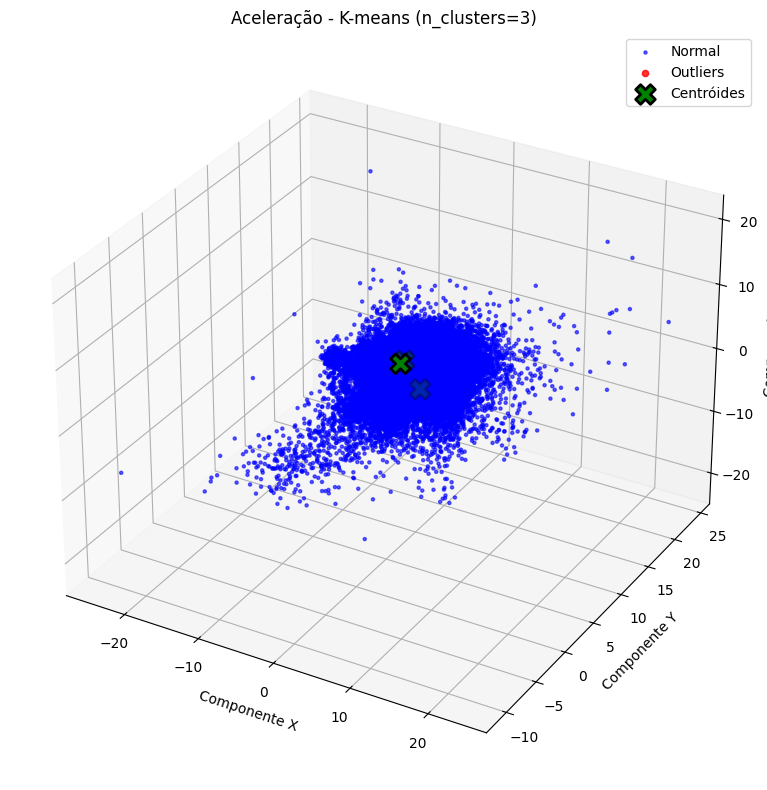


K-means com 5 clusters (accel):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(56474), np.int64(1): np.int64(74529), np.int64(2): np.int64(13124), np.int64(3): np.int64(96499), np.int64(4): np.int64(25614)}


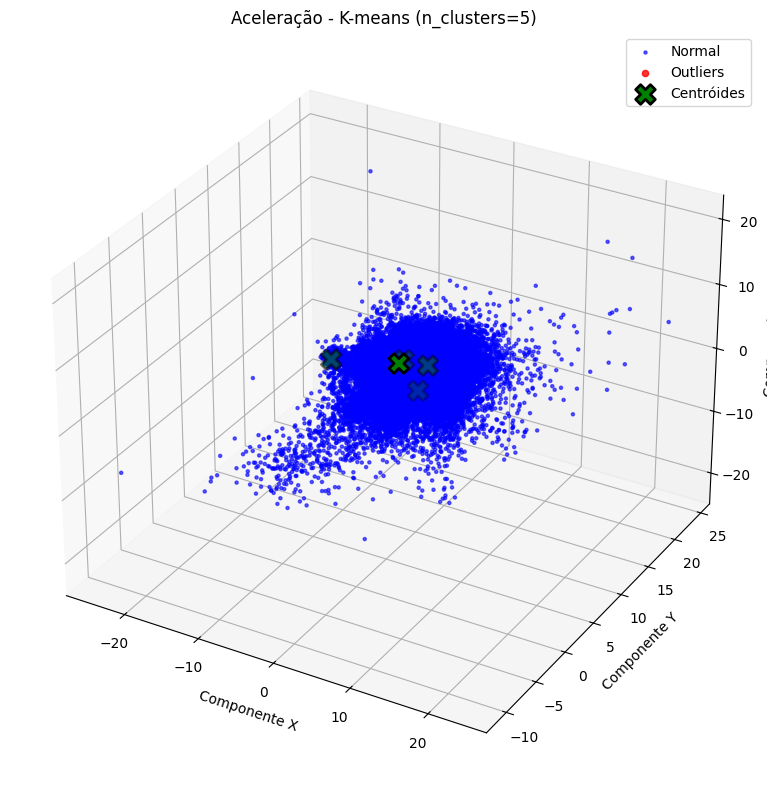


K-means com 6 clusters (accel):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(15010), np.int64(1): np.int64(76926), np.int64(2): np.int64(12882), np.int64(3): np.int64(99725), np.int64(4): np.int64(12972), np.int64(5): np.int64(48725)}


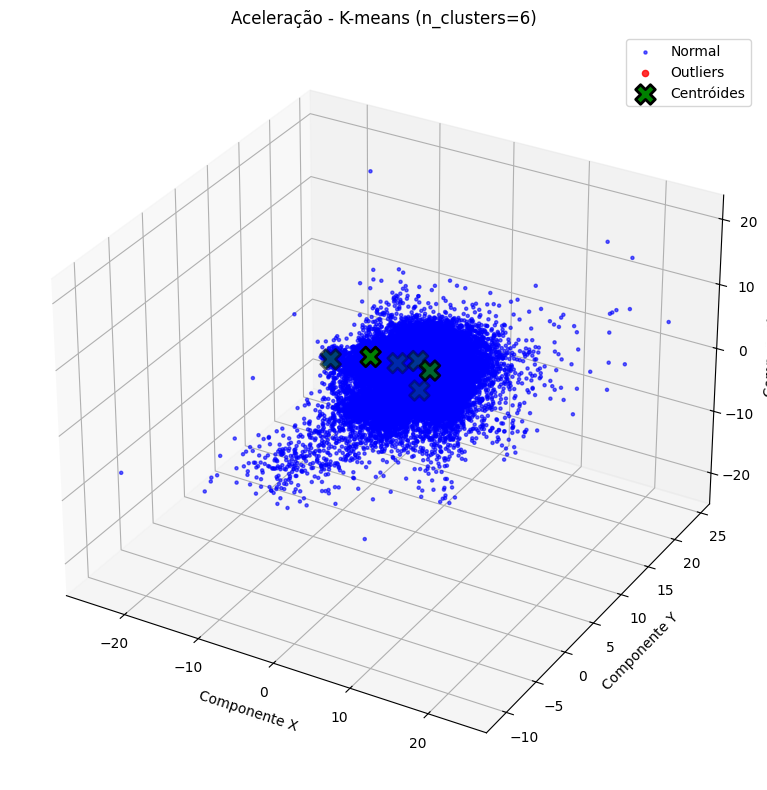


K-means com 3 clusters (gyro):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(13607), np.int64(1): np.int64(201202), np.int64(2): np.int64(51431)}


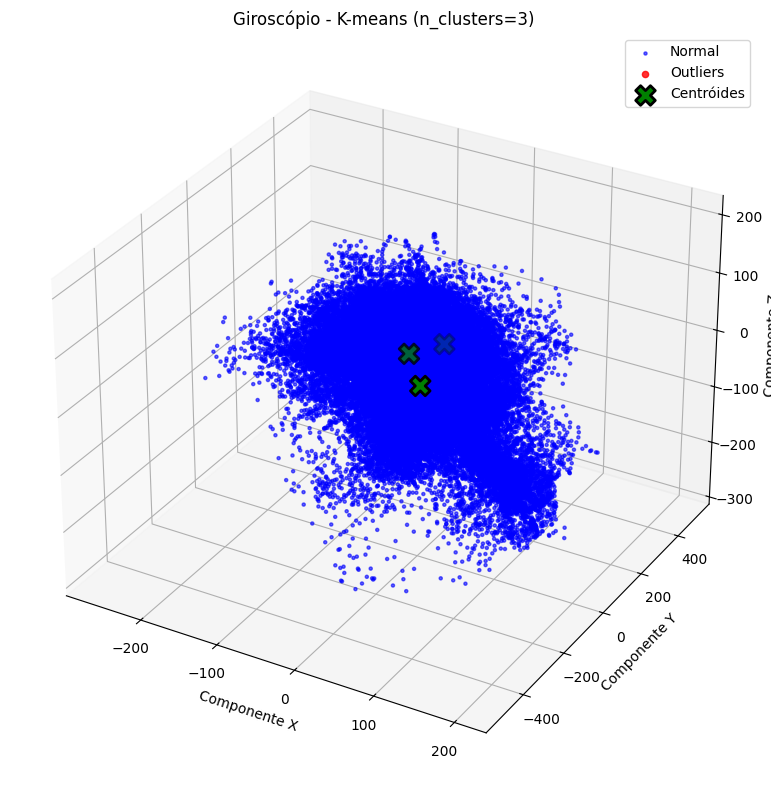


K-means com 5 clusters (gyro):
  Outliers detectados: 5935/266240 (2.23%)
  Distribuição por cluster: {np.int64(0): np.int64(12467), np.int64(1): np.int64(11024), np.int64(2): np.int64(37986), np.int64(3): np.int64(5935), np.int64(4): np.int64(198828)}


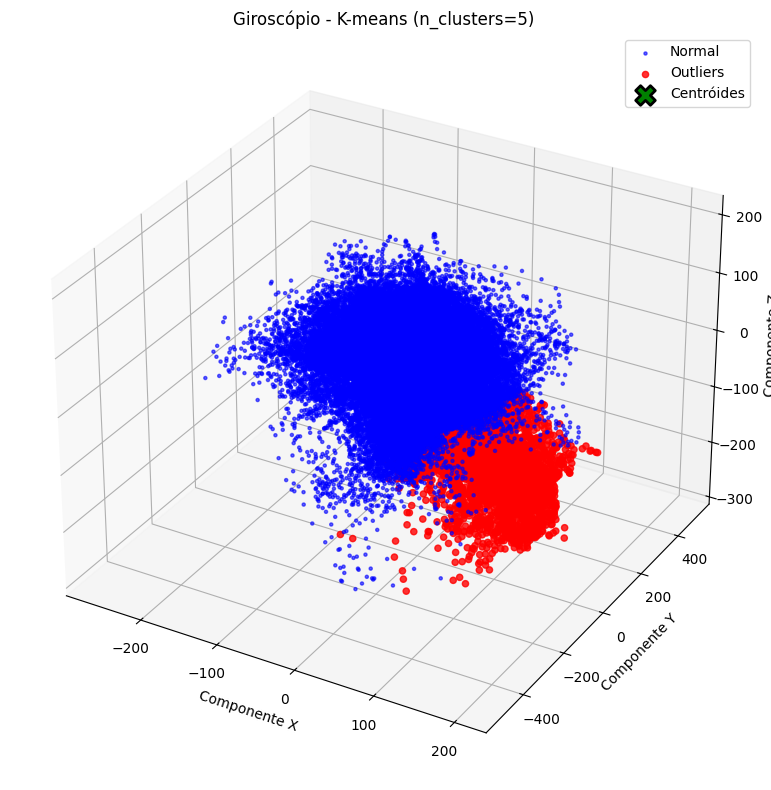


K-means com 6 clusters (gyro):
  Outliers detectados: 6085/266240 (2.29%)
  Distribuição por cluster: {np.int64(0): np.int64(35494), np.int64(1): np.int64(10466), np.int64(2): np.int64(11174), np.int64(3): np.int64(6085), np.int64(4): np.int64(193994), np.int64(5): np.int64(9027)}


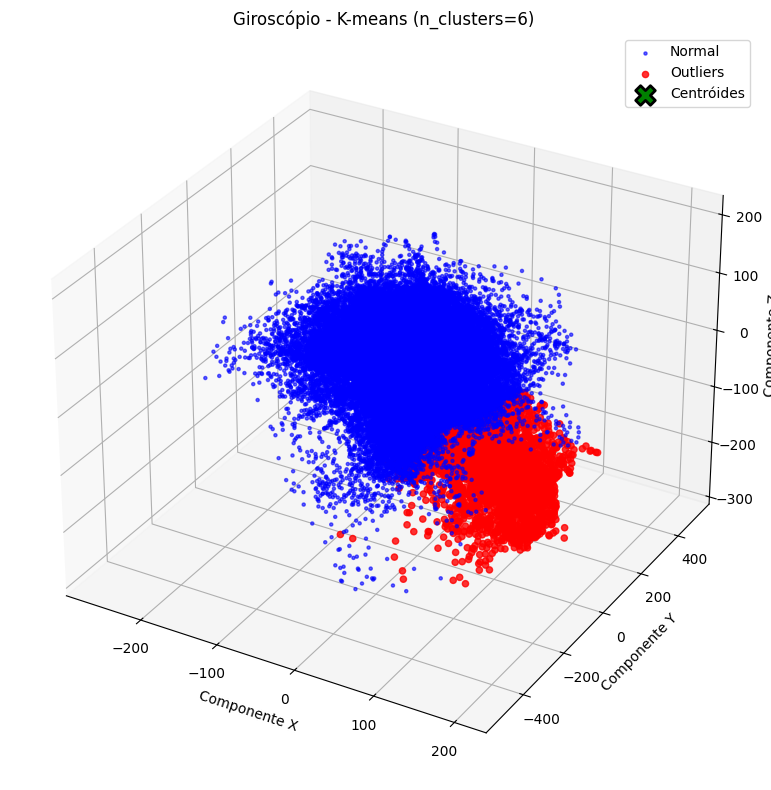


K-means com 3 clusters (mag):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(110695), np.int64(1): np.int64(80756), np.int64(2): np.int64(74789)}


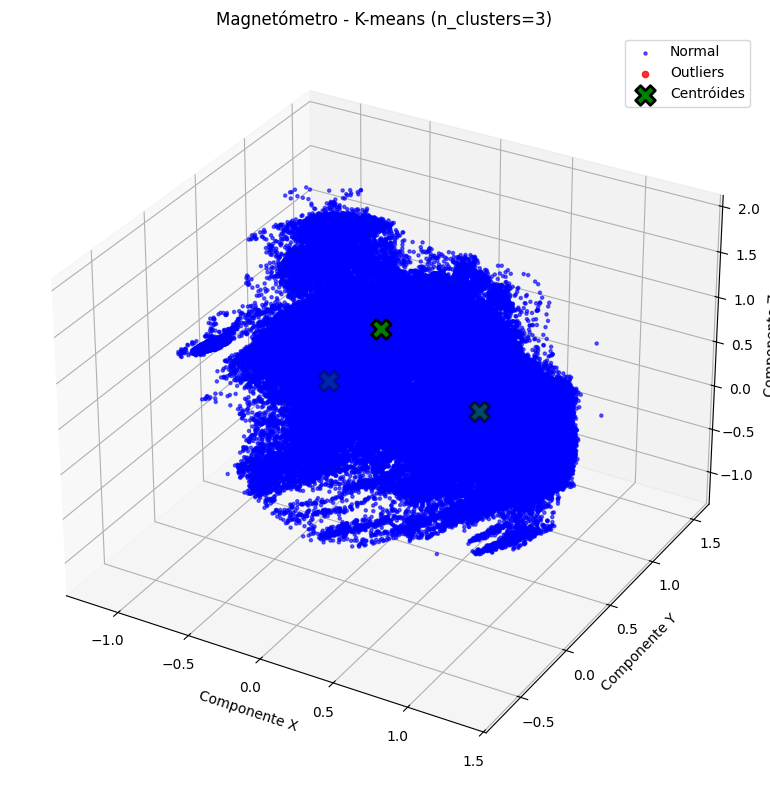


K-means com 5 clusters (mag):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(79944), np.int64(1): np.int64(50323), np.int64(2): np.int64(56693), np.int64(3): np.int64(48880), np.int64(4): np.int64(30400)}


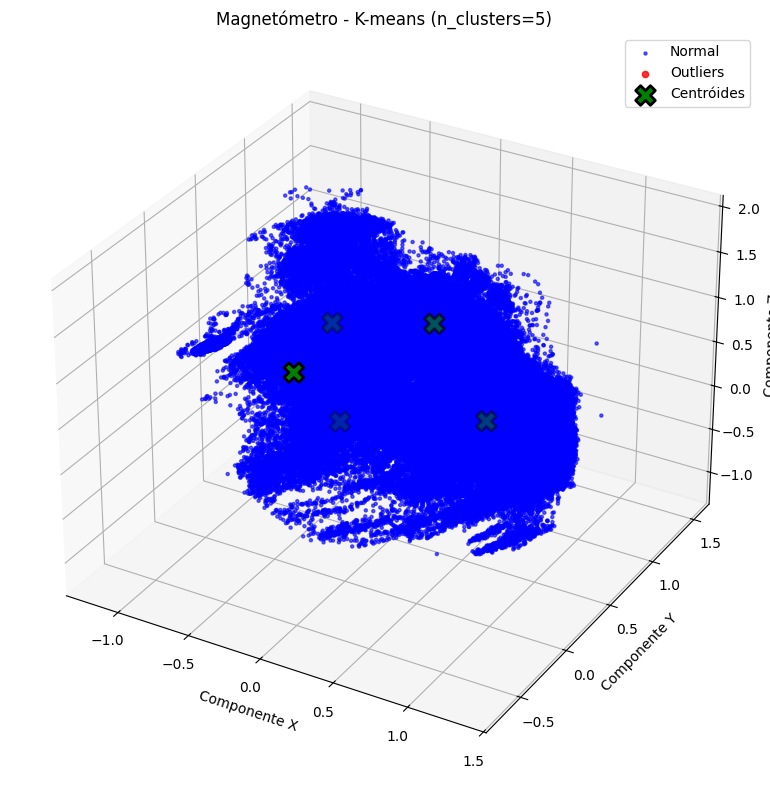


K-means com 6 clusters (mag):
  Outliers detectados: 0/266240 (0.00%)
  Distribuição por cluster: {np.int64(0): np.int64(46679), np.int64(1): np.int64(53458), np.int64(2): np.int64(32872), np.int64(3): np.int64(60582), np.int64(4): np.int64(24490), np.int64(5): np.int64(48159)}


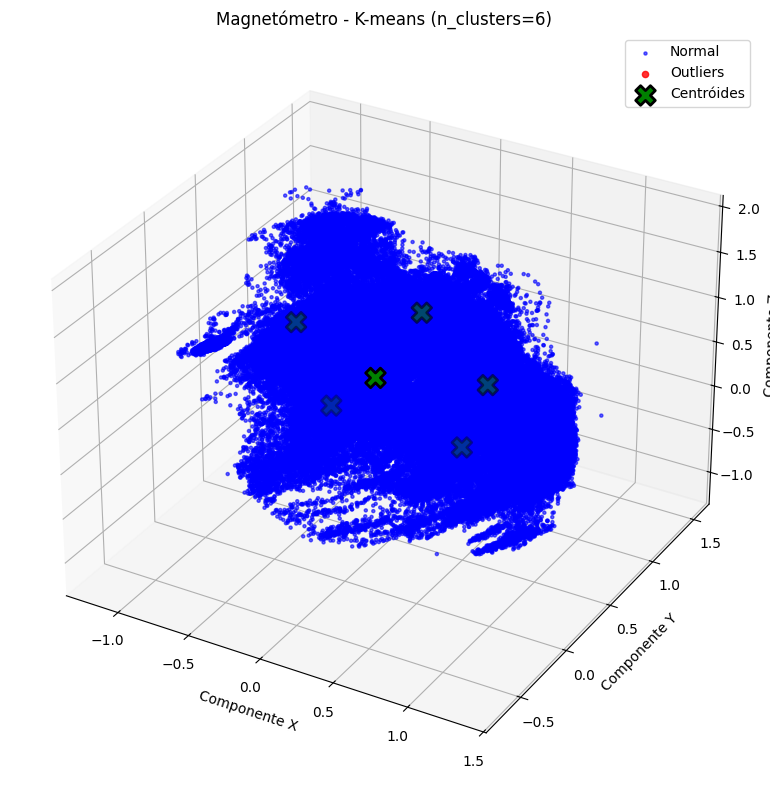

In [74]:
def detectar_outliers_kmeans(data_array, vector_type='accel', n_clusters=4):

    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Extrair os 3 componentes do vetor
    data_3d = data_array[:, start_col:start_col + 3]

    # Aplicar K-means
    labels, centroids = k_means(data_3d, n_clusters, random_state=42)

    # Contar pontos em cada cluster
    unique_labels, counts = np.unique(labels, return_counts=True)

    # Clusters com menos de 3% dos dados são outliers
    threshold = len(data_3d) * 0.03
    outlier_clusters = unique_labels[counts < threshold]

    # Criar máscara de outliers
    outlier_mask = np.isin(labels, outlier_clusters)

    n_outliers = np.sum(outlier_mask)
    density = (n_outliers / len(data_3d)) * 100

    print(f"\nK-means com {n_clusters} clusters ({vector_type}):")
    print(f"  Outliers detectados: {n_outliers}/{len(data_3d)} ({density:.2f}%)")
    print(f"  Distribuição por cluster: {dict(zip(unique_labels, counts))}")

    return outlier_mask, labels, data_3d, centroids

def plot_outliers_kmeans_3d(data_array, vector_type='accel', n_clusters_list=[3, 4, 5, 6]):

    if vector_type == 'accel':
        title_base = 'Aceleração'
    elif vector_type == 'gyro':
        title_base = 'Giroscópio'
    elif vector_type == 'mag':
        title_base = 'Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    for n_clusters in n_clusters_list:
        outlier_mask, labels, data_3d, centroids = detectar_outliers_kmeans(
            data_array, vector_type, n_clusters
        )

        # Criar figura 3D
        fig = plt.figure(figsize=(10, 8))
        ax = fig.add_subplot(111, projection='3d')

        # Plotar pontos normais (azul)
        normal_points = data_3d[~outlier_mask]
        ax.scatter(normal_points[:, 0], normal_points[:, 1], normal_points[:, 2],
                   c='blue', s=5, alpha=0.6, label='Normal')

        # Plotar outliers (vermelho)
        outlier_points = data_3d[outlier_mask]
        ax.scatter(outlier_points[:, 0], outlier_points[:, 1], outlier_points[:, 2],
                   c='red', s=20, alpha=0.8, label='Outliers')

        # Plotar centros dos clusters (verde)
        ax.scatter(centroids[:, 0], centroids[:, 1], centroids[:, 2],
                   c='green', marker='X', s=200, label='Centróides', edgecolors='black', linewidths=2)

        ax.set_xlabel('Componente X')
        ax.set_ylabel('Componente Y')
        ax.set_zlabel('Componente Z')
        ax.set_title(f'{title_base} - K-means (n_clusters={n_clusters})')
        ax.legend()

        plt.tight_layout()
        plt.show(block=False)

def comparar_kmeans_vs_zscore(data_array, vector_type='accel', n_clusters=5, k=3):

    if vector_type == 'accel':
        start_col = 1
        label = 'Aceleração'
    elif vector_type == 'gyro':
        start_col = 4
        label = 'Giroscópio'
    elif vector_type == 'mag':
        start_col = 7
        label = 'Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    # Magnitude do vetor
    magnitude = calculate_vector_magnitude(data_array, start_col)

    # Outliers K-means
    outlier_mask_kmeans, _, _, _ = detectar_outliers_kmeans(data_array, vector_type, n_clusters)

    # Outliers Z-score
    media = np.mean(magnitude)
    desvio = np.std(magnitude)
    if desvio > 0:
        z_scores = (magnitude - media) / desvio
        outlier_mask_zscore = np.abs(z_scores) > k
    else:
        outlier_mask_zscore = np.zeros(len(magnitude), dtype=bool)

    # Estatísticas
    n_kmeans = np.sum(outlier_mask_kmeans)
    n_zscore = np.sum(outlier_mask_zscore)
    both = np.sum(outlier_mask_kmeans & outlier_mask_zscore)

    print(f"\n{'=' * 80}")
    print(f"COMPARAÇÃO: K-means vs Z-score ({label})")
    print(f"{'=' * 80}")
    print(f"Outliers K-means (n_clusters={n_clusters}): {n_kmeans} ({n_kmeans / len(magnitude) * 100:.2f}%)")
    print(f"Outliers Z-score (k={k}): {n_zscore} ({n_zscore / len(magnitude) * 100:.2f}%)")
    print(f"Outliers detectados por ambos: {both}")
    print(f"Concordância: {both / max(n_kmeans, n_zscore) * 100:.2f}% (dos detectados por K-means)")
    print(f"{'=' * 80}\n")

    return outlier_mask_kmeans, outlier_mask_zscore


for v in ['accel', 'gyro', 'mag']:
    plot_outliers_kmeans_3d (data, vector_type=v, n_clusters_list=[3, 5, 6])


## 4. Extração e Seleção de Características

### 4.1 Testes de significância

Para avaliar a significância das diferenças entre atividades, calculou-se primeiro a magnitude dos vetores dos sensores e separaram-se os dados por atividade. Em seguida, testou-se a normalidade de cada grupo utilizando o Kolmogorov-Smirnov. Caso todos os grupos apresentassem distribuição normal, aplicou-se a ANOVA; caso contrário, utilizou-se o teste Kruskal-Wallis, não paramétrico. Este procedimento permite determinar se as médias das magnitudes diferem significativamente entre atividades, fornecendo informação importante sobre quais variáveis dos sensores são mais discriminantes para a classificação das atividades.

In [75]:
def determinar_significancia_atividade(data_array, vector_type='accel'):
    if vector_type == 'accel':
        start_col = 1
        label = 'Aceleração'
    elif vector_type == 'gyro':
        start_col = 4
        label = 'Giroscópio'
    elif vector_type == 'mag':
        start_col = 7
        label = 'Magnetómetro'
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")

    magnitude = calculate_vector_magnitude(data_array, start_col)
    activities = data_array[:, 11]
    unique_activities = np.sort(np.unique(activities))
    grupos = [magnitude[activities == a] for a in unique_activities]

    normalidades = []
    for g in grupos:
        if len(g) > 0:
            std_g = np.std(g)
            if std_g == 0:
                normalidades.append(False)
            else:
                stat, p_val = kstest((g - np.mean(g)) / std_g, 'norm')
                normalidades.append(p_val > 0.05)
        else:
            normalidades.append(False)

    normal = all(normalidades)
    if normal:
        stat, p_value = f_oneway(*grupos)
        teste_usado = 'ANOVA (paramétrico)'
    else:
        stat, p_value = kruskal(*grupos)
        teste_usado = 'Kruskal-Wallis (não paramétrico)'

    print(f"\n{'=' * 80}")
    print(f"4.1 - Teste de significância ({label})")
    print(f"{'-' * 80}")
    print(f"Normalidade (todas as atividades normais?): {'Sim' if normal else 'Não'}")
    print(f"Teste usado: {teste_usado}")
    print(f"Estatística = {stat:.4f}, p-valor = {p_value:.6f}")
    print(f"{'=' * 80}\n")
    return {'vector': vector_type, 'teste': teste_usado, 'p_value': p_value, 'normal': normal}

for v in ['accel', 'gyro', 'mag']:
    determinar_significancia_atividade (data, vector_type=v)



4.1 - Teste de significância (Aceleração)
--------------------------------------------------------------------------------
Normalidade (todas as atividades normais?): Não
Teste usado: Kruskal-Wallis (não paramétrico)
Estatística = 2649.1260, p-valor = 0.000000


4.1 - Teste de significância (Giroscópio)
--------------------------------------------------------------------------------
Normalidade (todas as atividades normais?): Não
Teste usado: Kruskal-Wallis (não paramétrico)
Estatística = 189647.6025, p-valor = 0.000000


4.1 - Teste de significância (Magnetómetro)
--------------------------------------------------------------------------------
Normalidade (todas as atividades normais?): Não
Teste usado: Kruskal-Wallis (não paramétrico)
Estatística = 50804.4657, p-valor = 0.000000


4.1 - Teste de significância (Magnetómetro)
--------------------------------------------------------------------------------
Normalidade (todas as atividades normais?): Não
Teste usado: Kruskal-Wallis (não

### 4.2 Extração de features temporais e espectrais

As rotinas 'extract_temporal_features' e 'extract_spectral_features' calculam, respetivamente, as estatísticas temporais (média, desvio padrão, máximo, mínimo, energia) e as espectrais (potência média e frequência dominante) para cada eixo. Os dados são segmentados em janelas de 5 segundos com 50% de sobreposição ('sliding_window_segments'). Apenas segmentos com uma única atividade são considerados.

In [76]:
def sliding_window_segments(data_array, window_size_sec=5, overlap=0.5, fs=50):
    window_size = int(window_size_sec * fs)
    step_size = int(window_size * (1 - overlap))
    activities = data_array[:, 11]
    segments = []
    for start in range(0, len(data_array) - window_size + 1, step_size):
        end = start + window_size
        window = data_array[start:end]
        if len(np.unique(window[:, 11])) == 1:
            segments.append(window)
    return segments

def extract_temporal_features(segment, vector_type='accel'):
    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")
    features = []
    for i in range(start_col, start_col + 3):
        axis_data = segment[:, i]
        features.extend([np.mean(axis_data), np.std(axis_data),
                         np.max(axis_data), np.min(axis_data),
                         np.sum(axis_data ** 2) / len(axis_data)])
    return np.array(features)

def extract_spectral_features(segment, vector_type='accel', fs=50):
    if vector_type == 'accel':
        start_col = 1
    elif vector_type == 'gyro':
        start_col = 4
    elif vector_type == 'mag':
        start_col = 7
    else:
        raise ValueError("vector_type deve ser 'accel', 'gyro' ou 'mag'")
    features = []
    for i in range(start_col, start_col + 3):
        axis_data = segment[:, i]
        freqs, psd = welch(axis_data, fs=fs, nperseg=min(256, len(axis_data)))
        features.extend([np.mean(psd), freqs[np.argmax(psd)]])
    return np.array(features)

def extract_feature_vector(segment, vector_type='accel', fs=50):
    return np.concatenate([extract_temporal_features(segment, vector_type),
                           extract_spectral_features(segment, vector_type, fs)])

def extract_feature_set(data_array, vector_type='accel', window_size_sec=5, overlap=0.5, fs=50):
    segments = sliding_window_segments(data_array, window_size_sec, overlap, fs)
    X, y = [], []
    for segment in segments:
        X.append(extract_feature_vector(segment, vector_type, fs))
        y.append(int(segment[0, 11]))
    return np.array(X), np.array(y)


X_accel, y_accel = extract_feature_set(data, vector_type='accel')
X_gyro, y_gyro = extract_feature_set(data, vector_type='gyro')
X_mag, y_mag = extract_feature_set(data, vector_type='mag')
print(f" Features aceleração: {X_accel.shape}")
print(f" Features giroscópio: {X_gyro.shape}")
print(f" Features magnetómetro: {X_mag.shape}")

 Features aceleração: (1898, 21)
 Features giroscópio: (1898, 21)
 Features magnetómetro: (1898, 21)


### 4.3 PCA – Redução de dimensionalidade 

A função 'aplicar_pca' utiliza o método Principal Component Analysis para reduzir a dimensionalidade do vetor de features. O número de componentes é definido de modo a reter 95% da variância total. São apresentadas as variâncias explicadas por cada componente e a variância acumulada. Este processo permite reduzir redundâncias e simplificar o espaço de representação. Nesta função foi inicializado o PCA com a biblioteca sklearn.

In [77]:
def aplicar_pca(feature_set, n_components=0.95, vector_type='accel'):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(feature_set)

    print(f"\n{'=' * 80}")
    print(f"4.3 - PCA ({vector_type})")
    print(f"{'-' * 80}")
    print(f"Número de features originais: {feature_set.shape[1]}")
    print(f"Número de componentes principais: {X_pca.shape[1]}")
    print(f"Variância explicada por cada componente: {pca.explained_variance_ratio_}")
    print(f"Variância acumulada: {np.cumsum(pca.explained_variance_ratio_)}")
    print(f"{'=' * 80}\n")

    return X_pca, pca

aplicar_pca (X_accel, n_components=0.95, vector_type='accel')
aplicar_pca (X_gyro, n_components=0.95, vector_type='gyro')
aplicar_pca (X_mag, n_components=0.95, vector_type='mag')


4.3 - PCA (accel)
--------------------------------------------------------------------------------
Número de features originais: 21
Número de componentes principais: 3
Variância explicada por cada componente: [0.78532306 0.1219578  0.04995959]
Variância acumulada: [0.78532306 0.90728086 0.95724045]


4.3 - PCA (gyro)
--------------------------------------------------------------------------------
Número de features originais: 21
Número de componentes principais: 3
Variância explicada por cada componente: [0.83558354 0.0982806  0.06545505]
Variância acumulada: [0.83558354 0.93386414 0.99931919]


4.3 - PCA (mag)
--------------------------------------------------------------------------------
Número de features originais: 21
Número de componentes principais: 3
Variância explicada por cada componente: [0.69726481 0.18705023 0.09341035]
Variância acumulada: [0.69726481 0.88431505 0.9777254 ]



(array([[-0.58432941, -5.24619022, -3.06859958],
        [ 5.00316673,  0.83757954, -4.55292158],
        [-0.36372103, -5.1380306 , -2.93047238],
        ...,
        [22.19710095, -1.62896982,  4.79576601],
        [22.28419785, -1.665412  ,  4.96916405],
        [21.32500186, -1.2618026 ,  3.05525573]], shape=(1898, 3)),
 PCA(n_components=0.95))

### 4.5 e 4.6 Seleção de features – Fisher Score e ReliefF

Para identificar as features mais relevantes, aplicaram-se dois métodos de seleção: o Fisher Score e o ReliefF. O Fisher Score avalia cada feature com base na razão entre a variância entre classes e a variância dentro das classes, destacando as variáveis que melhor separam as atividades. O ReliefF considera a diferença entre amostras próximas da mesma classe e de classes diferentes, ponderando as features que distinguem melhor os vizinhos de classes distintas. Para cada método, foram selecionadas as 10 features com maior pontuação, permitindo reduzir o espaço de features e focar naquelas mais relevantes para a classificação das atividades. Esta abordagem complementa a redução dimensional do PCA, oferecendo uma seleção orientada à relevância das classes.

In [78]:
def fisher_score(X, y):
    """
    Calcula o Fisher Score para cada feature.
    X : ndarray (amostras x features)
    y : ndarray (labels)
    """
    classes = np.unique(y)
    n_features = X.shape[1]
    scores = np.zeros(n_features)

    for j in range(n_features):
        feature = X[:, j]
        overall_mean = np.mean(feature)
        num, den = 0, 0
        for c in classes:
            mask = y == c
            class_data = feature[mask]
            if len(class_data) > 1:
                class_mean = np.mean(class_data)
                class_var = np.var(class_data)
                num += len(class_data) * (class_mean - overall_mean) ** 2
                den += len(class_data) * class_var
        scores[j] = num / den if den > 0 else 0

    return scores


def reliefF(X, y, n_neighbors=10):
    """
    Implementação simplificada do algoritmo ReliefF.
    Usa distância euclidiana entre amostras.
    """
    from sklearn.neighbors import NearestNeighbors

    n_samples, n_features = X.shape
    scores = np.zeros(n_features)
    nn = NearestNeighbors(n_neighbors=n_neighbors + 1)
    nn.fit(X)
    neighbors = nn.kneighbors(X, return_distance=False)

    for i in range(n_samples):
        label = y[i]
        hits = X[neighbors[i][1:]][y[neighbors[i][1:]] == label]
        misses = X[neighbors[i][1:]][y[neighbors[i][1:]] != label]

        if len(hits) > 0:
            diff_hit = np.abs(X[i] - np.mean(hits, axis=0))
        else:
            diff_hit = np.zeros(n_features)

        if len(misses) > 0:
            diff_miss = np.abs(X[i] - np.mean(misses, axis=0))
        else:
            diff_miss = np.zeros(n_features)

        scores += diff_miss - diff_hit

    scores = np.maximum(scores, 0)
    return scores


def selecionar_melhores_features(X, y, metodo='fisher', top_n=10):
    """
    4.6 - Identifica as melhores features segundo Fisher Score ou ReliefF.
    """
    if metodo.lower() == 'fisher':
        scores = fisher_score(X, y)
        nome_metodo = "Fisher Score"
    elif metodo.lower() == 'relieff':
        scores = reliefF(X, y)
        nome_metodo = "ReliefF"
    else:
        raise ValueError("Método deve ser 'fisher' ou 'relieff'.")

    top_idx = np.argsort(scores)[::-1][:top_n]

    print(f"\n{'=' * 80}")
    print(f"4.6 - Top {top_n} Features segundo {nome_metodo}")
    print(f"{'-' * 80}")
    for rank, idx in enumerate(top_idx, 1):
        print(f"{rank:2d}. Feature {idx:3d}  |  Score = {scores[idx]:.5f}")
    print(f"{'=' * 80}\n")

    return top_idx, scores


selecionar_melhores_features (X_accel, y_accel, metodo='fisher', top_n=10)
selecionar_melhores_features (X_accel, y_accel, metodo='relieff', top_n=10)



4.6 - Top 10 Features segundo Fisher Score
--------------------------------------------------------------------------------
 1. Feature   6  |  Score = 2.79762
 2. Feature   7  |  Score = 2.66422
 3. Feature   1  |  Score = 1.71423
 4. Feature  11  |  Score = 1.43614
 5. Feature   9  |  Score = 1.07837
 6. Feature   5  |  Score = 0.91866
 7. Feature  17  |  Score = 0.83481
 8. Feature   2  |  Score = 0.52320
 9. Feature  15  |  Score = 0.51594
10. Feature  12  |  Score = 0.47536


4.6 - Top 10 Features segundo ReliefF
--------------------------------------------------------------------------------
 1. Feature   7  |  Score = 151.28140
 2. Feature   3  |  Score = 85.51911
 3. Feature   8  |  Score = 81.27023
 4. Feature   2  |  Score = 76.27912
 5. Feature   9  |  Score = 56.38327
 6. Feature   6  |  Score = 53.75791
 7. Feature  10  |  Score = 47.55506
 8. Feature  13  |  Score = 46.43134
 9. Feature   0  |  Score = 41.05804
10. Feature   1  |  Score = 31.45505


4.6 - Top 10 Features

(array([ 7,  3,  8,  2,  9,  6, 10, 13,  0,  1]),
 array([ 41.05804393,  31.45505488,  76.27912325,  85.51910882,
          0.        ,  18.4360336 ,  53.75790636, 151.28139575,
         81.27023053,  56.38326695,  47.55505619,  25.37702351,
         28.72712614,  46.43133613,   0.        ,   0.32829243,
          0.        ,   2.59401331,   0.        ,   0.        ,
          0.        ]))

## Conclusão - Parte A

O trabalho permitiu compreender todo o processo de análise de sinais multissensoriais aplicados à classificação de atividades humanas. Observou-se que a deteção e tratamento de outliers é crucial para garantir qualidade dos dados e reduzir enviesamentos. Os métodos baseados em estatística (IQR, Z-score) foram complementares aos métodos baseados em clustering (K-means). A extração de features temporais e espectrais revelou-se eficaz para distinguir atividades com diferentes padrões de movimento. O PCA mostrou-se útil para reduzir a dimensionalidade mantendo a maior parte da variância. Por fim, as técnicas de seleção de features (Fisher e ReliefF) destacaram variáveis mais discriminantes, facilitando o desenvolvimento futuro de modelos de classificação supervisionada. Em suma, a pipeline implementada segue boas práticas de ciência de dados e estabelece uma base sólida para trabalhos subsequentes de reconhecimento automático de atividades humanas.

# Meta 2

## 1. Data Augmentation

### 1.1. Balanceamento das atividades

Para analisar o balanceamento do dataset, contou-se o número de segmentos correspondentes a cada uma das atividades de 1 a 7. Este procedimento permite verificar se existem classes com número muito inferior de amostras, o que poderia afetar o treino e a performance do modelo de classificação. A contagem por atividade oferece uma visão clara da distribuição dos dados, e chegamos a conclusão que os dados não estão distribuídos igualmente


In [79]:
def analisar_balanceamento(X, y):
    """
    1.1 - Conta o número de amostras por atividade (apenas 1 a 7).
    Funciona para qualquer dos vetores: accel, gyro, mag.
    """
    atividades_validas = [1, 2, 3, 4, 5, 6, 7]
    contagem = {a: 0 for a in atividades_validas}

    for label in y:
        if label in contagem:
            contagem[label] += 1

    print("\n=== 1.1 - Balanceamento das Atividades (1 a 7) ===")
    for a, c in contagem.items():
        print(f"Atividade {a}: {c} segmentos")

    return contagem

print("\n=== Teste 1.1 ===")
analisar_balanceamento(X_accel, y_accel)


=== Teste 1.1 ===

=== 1.1 - Balanceamento das Atividades (1 a 7) ===
Atividade 1: 390 segmentos
Atividade 2: 217 segmentos
Atividade 3: 222 segmentos
Atividade 4: 347 segmentos
Atividade 5: 362 segmentos
Atividade 6: 231 segmentos
Atividade 7: 106 segmentos


{1: 390, 2: 217, 3: 222, 4: 347, 5: 362, 6: 231, 7: 106}

### 1.2. Implementação do SMOTE

Para aumentar a diversidade do dataset e corrigir possíveis desequilíbrios, aplicou-se o SMOTE (Synthetic Minority Over-sampling Technique). Este método gera novas amostras sintéticas para uma atividade específica, selecionando aleatoriamente amostras existentes e interpolando com vizinhos próximos no espaço de features. No exemplo apresentado, foram geradas 3 novas amostras da atividade 4, mantendo a coerência com os dados originais. O SMOTE é útil para melhorar o treino de modelos de classificação em classes minoritárias, reduzindo o viés causado por desequilíbrios no dataset.

In [80]:
def aplicar_smote(X, y, atividade, k=5, n_novos=10):
    """
    1.2 - Aplica SMOTE para gerar n_novos exemplos sintéticos da atividade especificada.
    Funciona com qualquer matriz X (accel, gyro ou mag).
    """
    X = np.array(X)
    y = np.array(y)

    # Filtrar apenas a atividade específica
    mask = y == atividade
    X_min = X[mask]

    if len(X_min) == 0:
        raise ValueError(f"Nenhuma amostra da atividade {atividade} disponível para SMOTE.")

    # kNN
    nn = NearestNeighbors(n_neighbors=min(k, len(X_min)))
    nn.fit(X_min)
    vizinhos = nn.kneighbors(return_distance=False)

    novos = []

    for _ in range(n_novos):
        # Escolher amostra base
        idx = random.randint(0, len(X_min) - 1)
        base = X_min[idx]

        # Escolher vizinho
        nn_idx = random.choice(vizinhos[idx])
        neigh = X_min[nn_idx]

        # Geração SMOTE
        alpha = np.random.rand()
        sint = base + alpha * (neigh - base)
        novos.append(sint)

    novos = np.array(novos)
    novos_labels = np.full(n_novos, atividade)

    print(f"\nGeradas {n_novos} novas amostras sintéticas para a atividade {atividade}.")

    return novos, novos_labels

print("\n=== Teste 1.2 ===")
aplicar_smote(X_accel, y_accel, atividade=4, k=5, n_novos=3)


=== Teste 1.2 ===

Geradas 3 novas amostras sintéticas para a atividade 4.


(array([[ 2.05414292e+00,  5.58363338e-01,  3.56047857e+00,
         -6.07368143e-02,  4.53210856e+00,  9.22423031e+00,
          8.01164086e-01,  1.15202700e+01,  7.54198009e+00,
          8.57283341e+01,  3.31871280e+00,  6.68095435e-01,
          4.58805928e+00,  1.84489452e+00,  1.14609158e+01,
          9.34400086e-03,  5.45079974e-01,  2.50677610e-02,
          1.20000000e+00,  1.85642945e-02,  1.20000000e+00],
        [ 2.00873849e-01,  3.02264008e+00,  8.03407155e+00,
         -2.26656127e+01,  9.21696408e+00,  9.87822955e+00,
          2.40510857e+00,  1.58774371e+01,  3.61141349e+00,
          1.03364778e+02, -2.68276008e+00,  2.75901239e+00,
          7.19369958e+00, -1.99323905e+01,  1.48497124e+01,
          3.95925100e-01,  1.20000000e+00,  2.48053995e-01,
          1.20000000e+00,  3.44018106e-01,  6.00000000e-01],
        [ 2.09484388e+00,  1.33069105e+00,  5.68534177e+00,
         -2.12110597e+00,  6.15929452e+00,  9.52626486e+00,
          1.30408389e+00,  1.61710000e

### 1.3. Visualização das amostras sintéticas

Para visualizar a geração de dados sintéticos, foram criadas três amostras da atividade 4 do participante 3 utilizando SMOTE. As amostras são exibidas num scatter plot considerando apenas as duas primeiras features, onde os pontos reais aparecem coloridos de acordo com a atividade e os pontos sintéticos são destacados em vermelho com um marcador distinto. Esta visualização permite verificar de forma intuitiva como os novos exemplos se distribuem no espaço de features e confirma que o SMOTE mantém coerência com os dados originais, aumentando a variedade do conjunto de treino sem introduzir valores fora do padrão.


=== Teste 1.3 ===

Geradas 3 novas amostras sintéticas para a atividade 4.


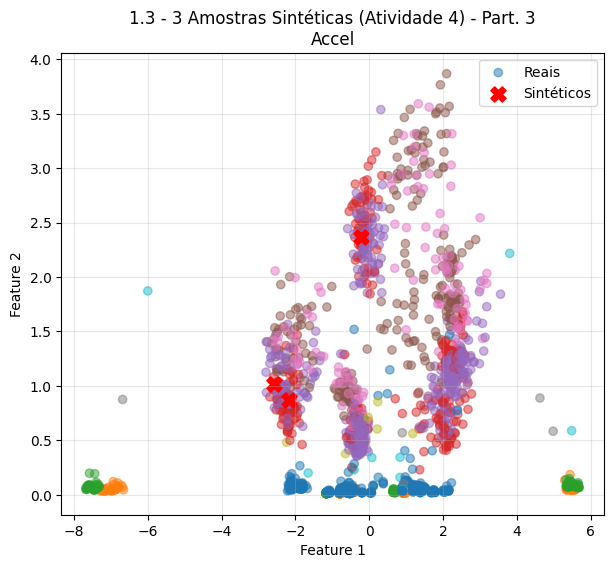


 Gráfico das novas amostras sintéticas.


(array([[-2.12679870e-01,  2.37132546e+00,  5.71543646e+00,
         -1.43979646e+01,  5.67433159e+00,  9.64247288e+00,
          2.11890284e+00,  1.41783369e+01,  3.30110770e+00,
          9.74730889e+01, -2.70499242e+00,  2.76499502e+00,
          3.56528963e+00, -1.82399806e+01,  1.49654244e+01,
          2.10835512e-01,  1.73189950e+00,  1.71161972e-01,
          1.73189950e+00,  3.19820954e-01,  6.00000000e-01],
        [-2.17109059e+00,  8.69385098e-01,  2.16765852e-01,
         -4.53048888e+00,  5.47662663e+00,  9.45171545e+00,
          7.67436417e-01,  1.17410844e+01,  7.94977427e+00,
          8.99250323e+01,  1.97336262e+00,  4.23681052e-01,
          2.91029349e+00,  9.78152227e-01,  4.07375260e+00,
          2.73072313e-02,  1.20000000e+00,  2.54205639e-02,
          1.20000000e+00,  6.38829087e-03,  2.59588748e-01],
        [-2.59105748e+00,  1.01833357e+00, -5.70638001e-01,
         -6.00449511e+00,  7.75368596e+00,  9.44913391e+00,
          1.07615722e+00,  1.26970000e

In [81]:
def visualizar_sinteticos_part3(X, y, atividade=4, n_sint=3, titulo=""):
    """
    1.3 - Visualiza 3 amostras sintéticas (apenas participante 3),
    usando apenas as primeiras 2 features num scatter plot.
    """
    novos, novos_labels = aplicar_smote(X, y, atividade, k=5, n_novos=n_sint)

    # Apagar tudo exceto as 2 primeiras features
    X_vis = X[:, :2]
    novos_vis = novos[:, :2]

    # Plot
    plt.figure(figsize=(7, 6))

    # Dados reais
    plt.scatter(X_vis[:, 0], X_vis[:, 1],
                c=y, cmap='tab10', alpha=0.5, label='Reais')

    # Dados sintéticos
    plt.scatter(novos_vis[:, 0], novos_vis[:, 1],
                c='red', marker='X', s=120, label='Sintéticos')

    plt.title(f"1.3 - 3 Amostras Sintéticas (Atividade {atividade}) - Part. 3\n{titulo}")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print("\n Gráfico das novas amostras sintéticas.")

    return novos, novos_labels

print("\n=== Teste 1.3 ===")
visualizar_sinteticos_part3(X_accel, y_accel, atividade=4, n_sint=3, titulo="Accel")

## 2. Embedding features

### 2.1 

A função 'load_embedding_model' é usada para carregar e preparar o modelo HARNet5. Em 'acc_segmentation_for_embeddings', os dados são divididos em segmentos de 5 segundos, e reamostrados para 30Hz através da função 'resample_segment_to_30hz' garantindo que todos têm a mesma duração temporal exigida pelo modelo. Por fim, a função 'create_embeddings_dataset' devolve um dataset de embeddings que vai ser usado nos pontos seguintes.

In [82]:
def load_embedding_model():
    print("A carregar modelo HARNet5")
    repo = 'OxWearables/ssl-wearables'
    model = torch.hub.load(repo, 'harnet5', class_num=5, pretrained=True)
    encoder = model.feature_extractor
    encoder.eval()
    encoder.to("cpu")
    return encoder

# ---------- Segmentação ACC ----------
def acc_segmentation_for_embeddings(data):
    TIMESTAMP_COL = 10
    MIN_SEGMENT_SIZE = 20
    fs_in_hz = 51.5
    win_size = 5000

    start_time = data[0, TIMESTAMP_COL]
    end_time = start_time + win_size

    activities = []
    segments = []

    while end_time < data[-1, TIMESTAMP_COL]:
        mask = (data[:, TIMESTAMP_COL] >= start_time) & (data[:, TIMESTAMP_COL] < end_time)

        if np.sum(mask) > MIN_SEGMENT_SIZE and np.all(data[mask, -1] == data[mask, -1][0]):
            acc_xyz = data[mask, 1:4]
            activity = int(data[mask, -1][0])

            segments.append(acc_xyz)
            activities.append(activity)

        start_time = end_time - win_size/2
        end_time = start_time + win_size

    return segments, activities


# ---------- Reamostragem para 30 Hz ----------
def resample_segment_to_30hz(segment, fs_in=51.5):
    win_size = 5
    fs_target = 30.0

    t_in = np.arange(segment.shape[0]) / fs_in
    t_out = np.arange(0, win_size, 1.0 / fs_target)

    res = np.zeros((len(t_out), 3), dtype=np.float32)
    for i in range(3):
        res[:, i] = np.interp(t_out, t_in, segment[:, i])
    return res


# ---------- Criar dataset de embeddings ----------
def create_embeddings_dataset(data):

    encoder = load_embedding_model()

    print("A segmentar ACC...")
    segments, activities = acc_segmentation_for_embeddings(data)

    print(f"Segmentos obtidos: {len(segments)}")

    # Reamostrar cada segmento
    print("A reamostrar para 30 Hz...")
    resampled = [resample_segment_to_30hz(seg) for seg in segments]

    # Preparar tensor para o modelo (N, C, T)
    x_all = np.transpose(np.array(resampled), (0, 2, 1))  # → (N, 3, T)

    embeddings_list = []
    batch_size = 16

    print("A gerar embeddings...")
    with torch.no_grad():
        for i in range(0, x_all.shape[0], batch_size):
            xb = torch.from_numpy(x_all[i:i+batch_size]).float()
            eb = encoder(xb)
            embeddings_list.append(eb.cpu().numpy())

    X_emb = np.concatenate(embeddings_list, axis=0)
    y_emb = np.array(activities)

    print(f"Embedding dataset criado: {X_emb.shape}")
    print(f"Labels: {y_emb.shape}")

    return X_emb, y_emb

## 3. Data splitting

#### 3.1. Divisão dentro do sujeito

Nesta parte do código, é implementada uma pipeline completa de carregamento, processamento e preparação dos dados para posterior utilização em modelos de classificação. São carregados os dados dos 15 participantes através da função 'load_participant_data' utilizada no exercicio dois da Meta 1 e gera um conjunto de features e outro de embeddings para cada um. Após percorrer todos os participantes, o código concatena as listas individuais, formando dois datasets completos: um dataset de features e um dataset de embeddings. Por fim, é realizado o split dentro do sujeito (60-20-20%).

   > A processar Part 2... A carregar modelo HARNet5


Using cache found in /home/andr-ramos/.cache/torch/hub/OxWearables_ssl-wearables_main


131 Weights loaded
A segmentar ACC...
Segmentos obtidos: 341
A reamostrar para 30 Hz...
A gerar embeddings...
Embedding dataset criado: (341, 512, 1)
Labels: (341,)
   > A processar Part 0... A carregar modelo HARNet5


Using cache found in /home/andr-ramos/.cache/torch/hub/OxWearables_ssl-wearables_main


131 Weights loaded
A segmentar ACC...
Segmentos obtidos: 351
A reamostrar para 30 Hz...
A gerar embeddings...
Embedding dataset criado: (351, 512, 1)
Labels: (351,)
   > A processar Part 1... A carregar modelo HARNet5


...

131 Weights loaded
A segmentar ACC...
Segmentos obtidos: 335
A reamostrar para 30 Hz...
A gerar embeddings...
Embedding dataset criado: (335, 512, 1)
Labels: (335,)
   > A processar Part 13... A carregar modelo HARNet5


Using cache found in /home/andr-ramos/.cache/torch/hub/OxWearables_ssl-wearables_main


131 Weights loaded
A segmentar ACC...
Segmentos obtidos: 347
A reamostrar para 30 Hz...
A gerar embeddings...
Embedding dataset criado: (347, 512, 1)
Labels: (347,)
   > A processar Part 14... A carregar modelo HARNet5


Using cache found in /home/andr-ramos/.cache/torch/hub/OxWearables_ssl-wearables_main


131 Weights loaded
A segmentar ACC...
Segmentos obtidos: 340
A reamostrar para 30 Hz...
A gerar embeddings...
Embedding dataset criado: (340, 512, 1)
Labels: (340,)

 DATASET CARREGADO:
   Features:   X=(27628, 21), Sujeitos=(27628,)
   Embeddings: X=(5130, 512), Sujeitos=(5130,)

 A executar Split 3.1
Features: Treino=16576, Val=5526, Teste=5526
Embeddings: Treino=3078, Val=1026, Teste=1026
 3.1 - Análise Visual da Distribuição (Boxplots)


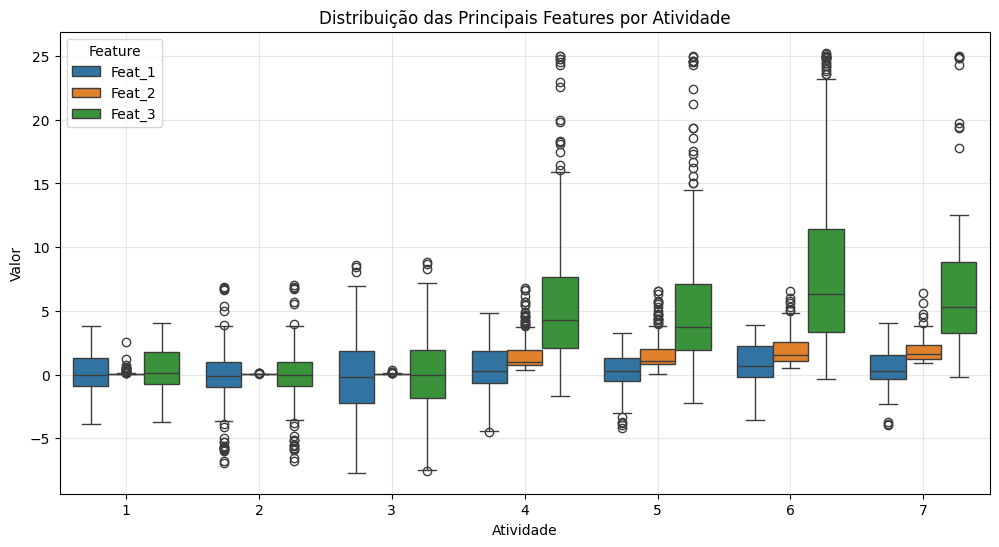

In [83]:
import numpy as np
from sklearn.model_selection import train_test_split

# --- 1. INICIALIZAÇÃO ---
X_features_list = []
y_features_list = []
subjects_list_feats = []  # Lista de sujeitos para as Features

X_embeddings_list = []
y_embeddings_list = []
subjects_list_embs = []   # Lista de sujeitos para os Embeddings

# --- 2. LOOP DE CARREGAMENTO ---
for participant_id, data_raw in datas_list.items():
    print(f"   > A processar Part {participant_id}...", end=" ")
    
    try:
        # --- A. FEATURES MANUAIS ---
        # Extrair a partir dos dados em memória
        X_f, y_f = extract_feature_set(data_raw, vector_type='accel')
        
        # Filtro (Atividades 1 a 7)
        mask = y_f <= 7
        X_f = X_f[mask]
        y_f = y_f[mask]
        
        if len(X_f) > 0:
            X_features_list.append(X_f)
            y_features_list.append(y_f)
            subjects_list_feats.append(np.full(len(y_f), participant_id))
            
        # --- B. EMBEDDINGS ---
        # Extrair a partir dos dados em memória
        X_e, y_e = create_embeddings_dataset(data_raw)
        
        if len(X_e) > 0:
            X_embeddings_list.append(X_e)
            y_embeddings_list.append(y_e)
            subjects_list_embs.append(np.full(len(y_e), participant_id))
        
    except Exception as e:
        print(f"Erro: {e}")

    except Exception as e:
        print(f" Erro: {e}")

# --- 3. CONCATENAÇÃO FINAL ---
# Para Features
if len(X_features_list) > 0:
    X_features_all = np.concatenate(X_features_list, axis=0)
    y_features_all = np.concatenate(y_features_list, axis=0)
    subjects_all_feats = np.concatenate(subjects_list_feats, axis=0) 

    # Para Embeddings
    X_embeddings_all = np.concatenate(X_embeddings_list, axis=0)
    y_embeddings_all = np.concatenate(y_embeddings_list, axis=0)
    subjects_all_embs = np.concatenate(subjects_list_embs, axis=0) 
    
    # Garantir 2D se vier 3D
    if X_embeddings_all.ndim > 2:
        X_embeddings_all = X_embeddings_all.reshape(X_embeddings_all.shape[0], -1)

    print("\n DATASET CARREGADO:")
    print(f"   Features:   X={X_features_all.shape}, Sujeitos={subjects_all_feats.shape}")
    print(f"   Embeddings: X={X_embeddings_all.shape}, Sujeitos={subjects_all_embs.shape}")
else:
    print(" Erro: Nenhum dado foi carregado.")


# ==============================================================================
# 3.1 - SPLIT WITHIN-SUBJECT (60-20-20)
# ==============================================================================

def split_within_subject(X, y):
    # 1. Separar 60% para Treino e 40% para Temp (Validação + Teste)
    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y, test_size=0.4, random_state=42, stratify=y
    )
    
    # 2. Dividir os 40% restantes em metades iguais (20% total cada)
    X_val, X_test, y_val, y_test = train_test_split(
        X_temp, y_temp, test_size=0.5, random_state=42
    )
    
    return X_train, y_train, X_val, y_val, X_test, y_test

if len(X_features_list) > 0:
    print("\n A executar Split 3.1")

    # Aplicar às Features Manuais
    Xf_train, yf_train, Xf_val, yf_val, Xf_test, yf_test = split_within_subject(X_features_all, y_features_all)

    # Aplicar aos Embeddings
    Xe_train, ye_train, Xe_val, ye_val, Xe_test, ye_test = split_within_subject(X_embeddings_all, y_embeddings_all)

    print(f"Features: Treino={len(yf_train)}, Val={len(yf_val)}, Teste={len(yf_test)}")
    print(f"Embeddings: Treino={len(ye_train)}, Val={len(ye_val)}, Teste={len(ye_test)}")


def plot_boxplot_inicial(data_features, data_labels):
    print(" 3.1 - Análise Visual da Distribuição (Boxplots)")
    
    # Usar apenas as primeiras 3 features (ex: Média X, Y, Z) para não poluir
    plt.figure(figsize=(12, 6))
    
    # Criar um DataFrame temporário para facilitar o plot
    df_temp = pd.DataFrame(data_features[:, :3], columns=['Feat_1', 'Feat_2', 'Feat_3'])
    df_temp['Atividade'] = data_labels
    
    # Derreter para formato longo
    df_long = pd.melt(df_temp, id_vars=['Atividade'], var_name='Feature', value_name='Valor')
    
    sns.boxplot(x='Atividade', y='Valor', hue='Feature', data=df_long)
    plt.title("Distribuição das Principais Features por Atividade")
    plt.grid(True, alpha=0.3)
    plt.show()

# Executar com uma amostra (Features Manuais)
if 'X_features_all' in locals():
    # Usar uma amostra de 1000 pontos para o gráfico ser rápido
    idx = np.random.choice(len(X_features_all), 1000)
    plot_boxplot_inicial(X_features_all[idx], y_features_all[idx])

### 3.2. Divisão de sujeitos

A função 'split_between_subjects' divide aleatoriamente os dados por participantes (9 treino, 3 validação, 3 teste). A função cria então máscaras booleanas que selecionam apenas as amostras pertencentes aos sujeitos definidos para cada conjunto. No final, são retornados os vetores X e y já separados nas três partições (treino, validação, teste), tanto para o dataset de features manuais como para o dataset de embeddings, e é imprimida a informação acerca dos participantes selecionados para cada grupo, assim como a dimensão final de cada dataset

In [84]:
def split_between_subjects(X, y, subjects, random_state=42):
    """
    Divide os dados por participantes (9 Treino, 3 Validação, 3 Teste).
    """
    unique_subs = np.unique(subjects)
    np.random.seed(random_state)
    shuffled_subs = np.random.permutation(unique_subs)
    
    # Definir grupos (9 Treino, 3 Validação, Resto Teste)
    # Ajuste de segurança caso haja menos participantes
    n_train = 9
    n_val = 3
    if len(unique_subs) < 12:
        n_train = int(len(unique_subs) * 0.6)
        n_val = int(len(unique_subs) * 0.2)
    
    train_subs = shuffled_subs[:n_train]
    val_subs = shuffled_subs[n_train : n_train + n_val]
    test_subs = shuffled_subs[n_train + n_val :]
    
    print(f"  > Participantes ({len(unique_subs)}): Treino={train_subs} | Val={val_subs} | Teste={test_subs}")
    
    # Criar máscaras booleanas
    mask_train = np.isin(subjects, train_subs)
    mask_val   = np.isin(subjects, val_subs)
    mask_test  = np.isin(subjects, test_subs)
    
    return X[mask_train], y[mask_train], X[mask_val], y[mask_val], X[mask_test], y[mask_test]

print(" A executar Split 3.2 (Between-Subjects)")

# FEATURES MANUAIS (Usa 'subjects_all_feats')
# -----------------------------------------------------------
if 'subjects_all_feats' in locals():
    print("\n--- A. FEATURES DATASET ---")
    Xf_train_b, yf_train_b, Xf_val_b, yf_val_b, Xf_test_b, yf_test_b = split_between_subjects(
        X_features_all, y_features_all, subjects_all_feats
    )
    print(f" Features: Treino={len(yf_train_b)}, Val={len(yf_val_b)}, Teste={len(yf_test_b)}")
else:
    print(" Erro: 'subjects_all_feats' não existe. Corre o carregamento primeiro.")

# EMBEDDINGS (Usa 'subjects_all_embs')
# -----------------------------------------------------------
if 'subjects_all_embs' in locals():
    print("\n--- B. EMBEDDINGS DATASET ---")
    Xe_train_b, ye_train_b, Xe_val_b, ye_val_b, Xe_test_b, ye_test_b = split_between_subjects(
        X_embeddings_all, y_embeddings_all, subjects_all_embs
    )
    print(f" Embeddings: Treino={len(ye_train_b)}, Val={len(ye_val_b)}, Teste={len(ye_test_b)}")
else:
    print(" Erro: 'subjects_all_embs' não existe. Corre o carregamento primeiro.")

 A executar Split 3.2 (Between-Subjects)

--- A. FEATURES DATASET ---
  > Participantes (15): Treino=[ 9 11  0 13  5  8  2  1 14] | Val=[ 4  7 10] | Teste=[12  3  6]
 Features: Treino=16586, Val=5410, Teste=5632

--- B. EMBEDDINGS DATASET ---
  > Participantes (15): Treino=[ 9 11  0 13  5  8  2  1 14] | Val=[ 4  7 10] | Teste=[12  3  6]
 Embeddings: Treino=3378, Val=734, Teste=1018


### 3.3 Diferenças entre estratégias

Na estratégia within-subject (3.1), cada participante contribui com dados para treino, validação e teste. Isto faz com que o modelo seja avaliado em segmentos de pessoas que já viu durante o treino. O resultado tende a ser otimista, porque o modelo beneficia de padrões específicos de cada participante (movimento, postura, ruído dos sensores), que se repetem nos três conjuntos.

Na estratégia between-subject (3.2), cada participante pertence apenas a um dos conjuntos. Assim, o modelo é testado em pessoas totalmente novas, o que exige uma verdadeira capacidade de generalização e reflete melhor o uso real do sistema.

Por isso, a estratégia between-subject fornece uma estimativa mais fiável do desempenho em novos utilizadores, enquanto a estratégia within-subject tende a sobrestimar a performance.

### 3.4 Preparação de cenários

Na alínea 3.4, preparam-se três cenários distintos do dataset após a divisão em treino, validação e teste: (i) All Features, com todas as features normalizadas pelo treino; (ii) PCA, reduzindo a dimensionalidade mantendo 90% da variância; e (iii) ReliefF, selecionando as 15 features mais relevantes. Cada transformação é aplicada apenas com base no treino, garantindo ausência de data leakage. Os conjuntos resultantes são guardados para uso posterior na avaliação dos modelos, permitindo comparar diferentes estratégias de representação dos dados

In [85]:
def preparar_cenarios(X_train, X_val, X_test, y_train, nome_dataset="Dados"):
    """
    Gera os 3 cenários pedidos: All, PCA(90%), ReliefF(Top15).
    Aplica fit no train e transform em todos.
    """
    print(f"\n A processar cenários para: {nome_dataset}...")

    if X_train.ndim > 2:
        print(f" Detetado formato 3D {X_train.shape}. A converter para 2D...")
        X_train = X_train.reshape(X_train.shape[0], -1)
        X_val = X_val.reshape(X_val.shape[0], -1)
        X_test = X_test.reshape(X_test.shape[0], -1)

    
    dic_cenarios = {}
    
    # 1. NORMALIZAÇÃO (Obrigatório antes de PCA/KNN) 
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train) # Fit só no treino
    X_val_sc = scaler.transform(X_val)
    X_te_sc = scaler.transform(X_test)
    
    # --- CENÁRIO A: ALL FEATURES (Normalizadas)
    dic_cenarios['All'] = (X_tr_sc, X_val_sc, X_te_sc)
    
    # --- PCA (90%) --- 
    pca = PCA(n_components=0.90)
    X_tr_pca = pca.fit_transform(X_tr_sc) # Fit só no treino
    X_val_pca = pca.transform(X_val_sc)
    X_te_pca = pca.transform(X_te_sc)
    
    dic_cenarios['PCA'] = (X_tr_pca, X_val_pca, X_te_pca)
    print(f"   > PCA: Reduziu de {X_tr_sc.shape[1]} para {X_tr_pca.shape[1]} componentes.")
    
    # --- CENÁRIO C: ReliefF (Top 15) --- 
    # Calcular índices apenas com base no treino
    print("   > A calcular ReliefF")
    top_idx, _ = selecionar_melhores_features(X_tr_sc, y_train, metodo='relieff', top_n=15)
    
    X_tr_rel = X_tr_sc[:, top_idx]
    X_val_rel = X_val_sc[:, top_idx]
    X_te_rel = X_te_sc[:, top_idx]
    
    dic_cenarios['ReliefF'] = (X_tr_rel, X_val_rel, X_te_rel)
    print(f"   > ReliefF: Selecionadas {X_tr_rel.shape[1]} features.")
    
    return dic_cenarios

if 'Xf_train_b' in locals() and 'Xe_train_b' in locals():
    
    # 1. Cenários para FEATURES MANUAIS (Between-Subjects)
    cenarios_feat_between = preparar_cenarios(
        Xf_train_b, Xf_val_b, Xf_test_b, yf_train_b, "Features (Between-Subj)"
    )
    
    # 2. Cenários para EMBEDDINGS (Between-Subjects)
    cenarios_emb_between = preparar_cenarios(
        Xe_train_b, Xe_val_b, Xe_test_b, ye_train_b, "Embeddings (Between-Subj)"
    )
    
    print("Variáveis criadas: 'cenarios_feat_between' e 'cenarios_emb_between'")
    
else:
    print(" ERRO: Faltam as variáveis do Split 3.2 (Xf_train_b, etc).")
    print(" Correr a célula do Ponto 3.2 (Between-Subjects) antes desta.")


 A processar cenários para: Features (Between-Subj)...
   > PCA: Reduziu de 21 para 7 componentes.
   > A calcular ReliefF

4.6 - Top 15 Features segundo ReliefF
--------------------------------------------------------------------------------
 1. Feature   0  |  Score = 357.53322
 2. Feature   8  |  Score = 248.38182
 3. Feature   5  |  Score = 205.76031
 4. Feature   9  |  Score = 203.73207
 5. Feature   4  |  Score = 192.56259
 6. Feature   7  |  Score = 182.23193
 7. Feature  10  |  Score = 181.89437
 8. Feature   6  |  Score = 163.27996
 9. Feature  14  |  Score = 141.65906
10. Feature   2  |  Score = 113.73290
11. Feature   3  |  Score = 101.31445
12. Feature  13  |  Score = 99.66906
13. Feature  17  |  Score = 96.29568
14. Feature  12  |  Score = 74.32042
15. Feature   1  |  Score = 73.90524

   > ReliefF: Selecionadas 15 features.

 A processar cenários para: Embeddings (Between-Subj)...
   > PCA: Reduziu de 512 para 8 componentes.
   > A calcular ReliefF

4.6 - Top 15 Features

## 4. Model Learning

### 4.1. Classe KNNClassifier

A classe 'KNNClassifier' permite armazenar um conjunto de treino através do método fit e, posteriormente, prever a classe de novas amostras com o método predict. Para cada amostra de teste, calcula a distância euclidiana em relação a todos os pontos do treino, seleciona os k vizinhos mais próximos e retorna a classe mais frequente entre esses vizinhos. Esta implementação é útil para ilustrar o funcionamento do KNN, sendo interpretável e de fácil integração em pipelines de classificação de atividades humanas.

In [86]:
class KNNClassifier:
    """
    Implementação simples do algoritmo k-Nearest Neighbors.
    """
    def __init__(self, k=5):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        """
        Armazena o conjunto de treino.
        """
        self.X_train = np.array(X)
        self.y_train = np.array(y)

    def predict(self, X):
        """
        Para cada amostra em X, encontra os k vizinhos mais próximos 
        e devolve a classe mais comum.
        """
        X = np.array(X)
        y_pred = []

        for sample in X:
            # Distância euclidiana a todos os pontos do treino
            distances = np.linalg.norm(self.X_train - sample, axis=1)

            # Índices dos k vizinhos mais próximos
            idx = np.argsort(distances)[:self.k]

            # Classes desses vizinhos
            neighbor_labels = self.y_train[idx]

            # Classe mais frequente
            most_common = Counter(neighbor_labels).most_common(1)[0][0]

            y_pred.append(most_common)

        return np.array(y_pred)

### 4.2. Métricas de classificação

Nesta fase, avaliou-se o desempenho do classificador KNN usando o cenário completo de features (“All”). O modelo foi treinado com k=5 e aplicado ao conjunto de teste, sendo calculadas métricas como matriz de confusão, accuracy, precisão, recall e F1-score. A média ponderada garante que o desempenho reflita a importância de cada classe. Estes resultados permitem identificar atividades mais fáceis ou difíceis de classificar, orientando possíveis melhorias no modelo ou na seleção de features.

In [87]:
def classification_metrics(y_true, y_pred, verbose=True):
    """
    Devolve métricas de classificação usando previsões reais.
    """
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    report = classification_report(y_true, y_pred, zero_division=0)

    if verbose:
        print("=== 4.2 - Classification Metrics ===")
        print("\nConfusion Matrix:\n", cm)
        print(f"\nAccuracy : {acc:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall   : {recall:.4f}")
        print(f"F1-score : {f1:.4f}")
        print("\nClassification Report:\n", report)
        print("="*45)

    return {
        "confusion_matrix": cm,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "report": report
    }


# Escolher cenário (ALL, PCA ou ReliefF)
X_train, X_val, X_test = cenarios_feat_between["All"]
y_train, y_val, y_test = yf_train_b, yf_val_b, yf_test_b

# Usar KNN do ponto 4.1
knn = KNNClassifier(k=5)
knn.fit(X_train, y_train)

# Previsão real no conjunto de teste
y_pred_test = knn.predict(X_test)

# Métricas reais
results = classification_metrics(y_test, y_pred_test)

=== 4.2 - Classification Metrics ===

Confusion Matrix:
 [[1106   18   26    3    5    0    0]
 [  70  207  383    0    0    0    0]
 [  59  216  392    0    2    0    0]
 [   6    0    0  525  428  101   18]
 [  14    0    1  478  523   55   13]
 [   0    0    0  103   57  417   85]
 [   0    0    0   51   31  188   51]]

Accuracy : 0.5719
Precision: 0.5589
Recall   : 0.5719
F1-score : 0.5610

Classification Report:
               precision    recall  f1-score   support

           1       0.88      0.96      0.92      1158
           2       0.47      0.31      0.38       660
           3       0.49      0.59      0.53       669
           4       0.45      0.49      0.47      1078
           5       0.50      0.48      0.49      1084
           6       0.55      0.63      0.59       662
           7       0.31      0.16      0.21       321

    accuracy                           0.57      5632
   macro avg       0.52      0.52      0.51      5632
weighted avg       0.56      0.57   

## 5. Evaluation

### 5.1. Seleção de k

Para o hiperparâmetro k do KNN, testaram-se diversos valores usando apenas os conjuntos de treino e validação. Para cada k, treinou-se o modelo no treino, efetuou-se previsão na validação e calculou-se a accuracy. O valor de k que apresentou a maior accuracy na validação foi selecionado como o melhor k a utilizar na avaliação final do modelo.

In [88]:
def tune_knn_hyperparameter(X_train, y_train, X_val, y_val, k_values=[1,3,5,7,9,11,13,15]):
    """
    Procura o melhor k para KNN usando apenas treino e validação.
    """
    best_k = None
    best_acc = -np.inf
    
    for k in k_values:
        knn = KNNClassifier(k=k)
        knn.fit(X_train, y_train)
        y_pred = knn.predict(X_val)
        acc = np.mean(y_pred == y_val)
        
        print(f"k={k}: Accuracy={acc:.4f}")
        
        if acc > best_acc:
            best_acc = acc
            best_k = k
    
    print(f"\nMelhor k encontrado: {best_k} com accuracy={best_acc:.4f}")
    return best_k



# Exemplo: usar FEATURES dataset com split 3.2 e cenário ALL
X_train, X_val, X_test = cenarios_feat_between["All"]
y_train, y_val, y_test = yf_train_b, yf_val_b, yf_test_b

print("=== 5.1 - Tuning do K para FEATURES (cenário ALL) ===")
best_k_feat_all = tune_knn_hyperparameter(X_train, y_train, X_val, y_val)

print("\nMelhor k encontrado para FEATURES/ALL:", best_k_feat_all)



=== 5.1 - Tuning do K para FEATURES (cenário ALL) ===
k=1: Accuracy=0.5216
k=3: Accuracy=0.5396
k=5: Accuracy=0.5525
k=7: Accuracy=0.5501
k=9: Accuracy=0.5508
k=11: Accuracy=0.5569
k=13: Accuracy=0.5608
k=15: Accuracy=0.5595

Melhor k encontrado: 13 com accuracy=0.5608

Melhor k encontrado para FEATURES/ALL: 13


### 5.2. Discussão de resultados

Na alínea 5.2, treinou-se o KNN final combinando treino e validação e avaliou-se o modelo no conjunto de teste. A função 'train_and_evaluate_knn_fixed' utiliza os cenários preparados em 3.4, treina o modelo com o melhor k encontrado e calcula todas as métricas de classificação no teste, permitindo analisar o desempenho real do classificador para cada cenário e dataset.

A matriz de confusão mostra que algumas atividades são mais facilmente classificáveis e que outras, por exemplo, a atividade 1 apresenta elevada precisão e recall (0.85 e 0.92), indicando que o modelo identifica corretamente a maior parte dos exemplos desta classe. Em contraste, a atividade 7 tem um desempenho bastante baixo (precision 0.30, recall 0.09), mostrando que o modelo tem dificuldade em distingui-la das restantes, possivelmente devido a poucas amostras ou similaridade com outras atividades.

O valor global de accuracy (≈0.58) e F1-score ponderado (≈0.57) indica que o classificador consegue distinguir razoavelmente bem algumas atividades, mas ainda apresenta confusões significativas entre classes mais similares, como atividades 2 e 3 ou 4 e 5.

Em termos de dataset, neste caso foi utilizado o conjunto de features. Comparando com embeddings, em geral, embeddings tendem a capturar melhor padrões complexos do sinal e podem melhorar a classificação de atividades mais difíceis, mas isso depende do pré-treinamento do modelo e do ajuste dos hiperparâmetros.

Quanto à seleção de features (cenários PCA ou ReliefF), ela pode melhorar o desempenho ao reduzir ruído e focar nas features mais discriminativas. No entanto, neste resultado, usando todas as features, algumas atividades continuam a ser confundidas, sugerindo que feature selection poderia ajudar especialmente nas classes mais difíceis, mas não eliminaria todas as confusões.

Em resumo, atividades simples como estar sentado ou em pé são classificadas corretamente, enquanto atividades mais complexas ou semelhantes apresentam maior confusão. Melhorias poderiam incluir ajuste de k, normalização mais específica, ou uso de embeddings/seleção de features para aumentar a discriminabilidade.

In [89]:
# --- 5.2 corrigido ---
def train_and_evaluate_knn_fixed(scenario_dict, y_train_full, y_val_full, y_test_full,
                                 dataset_name="Features", scenario="All", k=5):
    """
    Treina KNN com treino+validação e avalia no conjunto de teste,
    usando diretamente os dados dos cenários preparados no 3.4.
    """
    print(f"\n=== Treino e avaliação final ({dataset_name}, cenário {scenario}) ===")
    
    # Extrair os conjuntos do cenário
    X_train, X_val, X_test = scenario_dict[scenario]
    y_train, y_val, y_test = y_train_full, y_val_full, y_test_full
    
    # Combinar treino + validação
    X_combined = np.concatenate([X_train, X_val], axis=0)
    y_combined = np.concatenate([y_train, y_val], axis=0)
    
    # Treinar KNN
    knn = KNNClassifier(k=k)
    knn.fit(X_combined, y_combined)
    
    # Prever no teste
    y_pred_test = knn.predict(X_test)
    
    # Obter métricas
    results = classification_metrics(y_test, y_pred_test)
    
    return knn, results

# Uso correto:
knn_model_feat_all, results_feat_all = train_and_evaluate_knn_fixed(
    cenarios_feat_between, yf_train_b, yf_val_b, yf_test_b,
    dataset_name="Features", scenario="All", k=best_k_feat_all
)



=== Treino e avaliação final (Features, cenário All) ===
=== 4.2 - Classification Metrics ===

Confusion Matrix:
 [[1060   57   31    3    7    0    0]
 [  76  281  303    0    0    0    0]
 [  86  204  379    0    0    0    0]
 [   6    1    0  553  430   83    5]
 [  14    0    1  494  537   36    2]
 [   0    0    0  109   72  419   62]
 [   0    0    0   49   37  206   29]]

Accuracy : 0.5785
Precision: 0.5653
Recall   : 0.5785
F1-score : 0.5674

Classification Report:
               precision    recall  f1-score   support

           1       0.85      0.92      0.88      1158
           2       0.52      0.43      0.47       660
           3       0.53      0.57      0.55       669
           4       0.46      0.51      0.48      1078
           5       0.50      0.50      0.50      1084
           6       0.56      0.63      0.60       662
           7       0.30      0.09      0.14       321

    accuracy                           0.58      5632
   macro avg       0.53      0.5

### 5.3. Comparação entre modelos

Na alínea 5.3, realiza-se uma avaliação robusta do KNN repetindo múltiplas vezes o split entre sujeitos (between-subjects). Para cada repetição, os dados são normalizados e transformados nos seis cenários definidos (Features/Embeddings × All/PCA/ReliefF). Em cada cenário, realiza-se tuning do hiperparâmetro k usando o conjunto de validação, seguido do treino final combinando treino e validação, e avaliação no teste. Os resultados de todas as repetições são guardados e resumidos em médias e desvios, permitindo identificar o cenário e configuração com melhor desempenho de forma estatisticamente consistente.
É gerado um boxplot comparativo, permitindo visualizar a distribuição das accuracies e identificar visualmente qual abordagem apresentou melhor desempenho. Esta análise completa a avaliação robusta do modelo, complementando a média e desvio das repetições com uma verificação estatística da superioridade de um modelo sobre o outro.

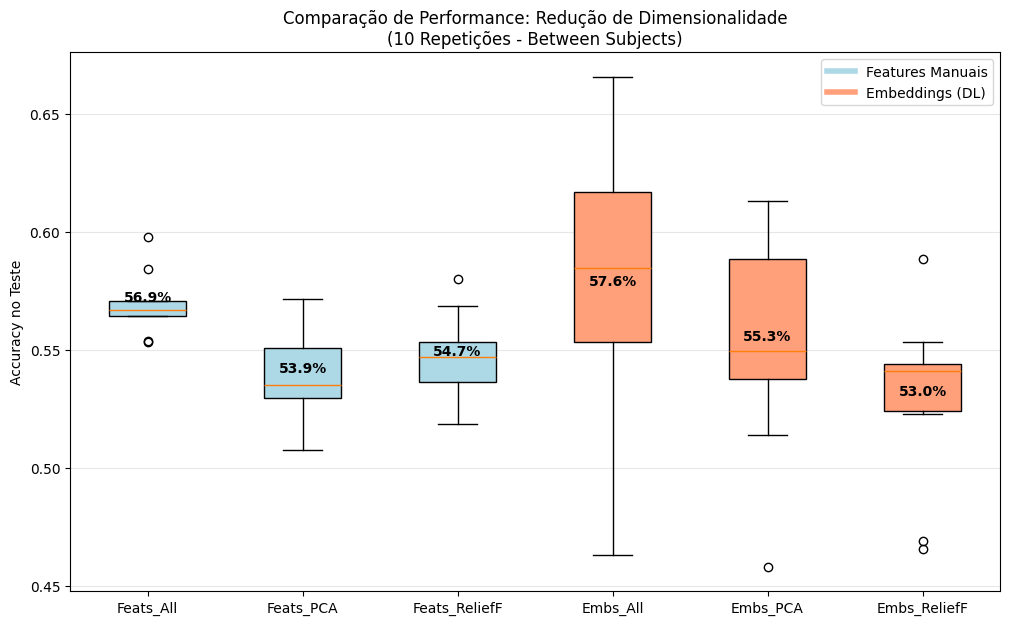


 RESUMO DAS MÉDIAS:
   > Feats_All      : 56.93%
   > Feats_PCA      : 53.94%
   > Feats_ReliefF  : 54.67%
   > Embs_All       : 57.63%
   > Embs_PCA       : 55.29%
   > Embs_ReliefF   : 52.98%


In [90]:
if 'historico_resultados' in locals():
    
    # 1. Preparar dados
    # Definimos a ordem para o gráfico ficar organizado
    ordem_cenarios = [
        "Feats_All", "Feats_PCA", "Feats_ReliefF",
        "Embs_All",  "Embs_PCA",  "Embs_ReliefF"
    ]
    
    dados_para_plot = []
    labels_finais = []
    medias = []
    
    for cenario in ordem_cenarios:
        if cenario in historico_resultados:
            scores = historico_resultados[cenario]
            dados_para_plot.append(scores)
            labels_finais.append(cenario)
            medias.append(np.mean(scores))
            
    # 2. Criar Boxplot
    plt.figure(figsize=(12, 7))
    
    # Cores: Azul para Features Manuais, Laranja para Embeddings
    cores = ['lightblue'] * 3 + ['lightsalmon'] * 3
    
    bplot = plt.boxplot(dados_para_plot, 
                        patch_artist=True,  # Para poder pintar
                        tick_labels=labels_finais)
    
    # Pintar as caixas
    for patch, color in zip(bplot['boxes'], cores):
        patch.set_facecolor(color)
        
    # Adicionar linhas de média
    for i, media in enumerate(medias):
        plt.text(i+1, media, f"{media:.1%}", 
                 ha='center', va='bottom', fontweight='bold', color='black')

    # Decoração
    plt.title(f"Comparação de Performance: Redução de Dimensionalidade\n({len(scores)} Repetições - Between Subjects)")
    plt.ylabel("Accuracy no Teste")
    plt.grid(True, alpha=0.3, axis='y')
    
    # Legenda manual
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='lightblue', lw=4, label='Features Manuais'),
        Line2D([0], [0], color='lightsalmon', lw=4, label='Embeddings (DL)')
    ]
    plt.legend(handles=legend_elements, loc='upper right')
    
    plt.show()
    
    # Imprimir tabela resumo
    print("\n RESUMO DAS MÉDIAS:")
    for nome, valor in zip(labels_finais, medias):
        print(f"   > {nome:15}: {valor:.2%}")

else:
    print(" Erro: Não encontrei a variável 'historico_resultados'. Corre o loop do Ponto 5.3 primeiro!")

## 6. Deployment

No Ponto 6, construiu-se o sistema de deployment, capaz de receber um segmento de dados brutos e devolver a atividade prevista. O KNN final é treinado com treino e validação combinados, usando o melhor k obtido anteriormente, e um scaler de normalização é definido com base nesses dados. A função 'classificar_atividade' aplica a pipeline completa: extração de features, normalização e classificação, retornando o ID e o nome da atividade. O sistema foi testado com um segmento simulado para validar o funcionamento da pipeline completa.

In [91]:
MELHOR_K = 13  # O valor que encontrado no tuning
DATASET_USADO = 'Features' # Ou 'Embeddings'

# Treinar o modelo final usando TODOS os dados de Treino + Validação

if 'cenarios_feat_between' in locals():
    # 1. Recuperar dados de Treino + Validação (para o modelo final saber o máximo possível)
    # Vamos usar o cenário 'All' (Features Normalizadas)
    X_tr_norm, X_val_norm, _ = cenarios_feat_between['All']
    
    # Juntar Treino e Validação (O modelo final deve treinar com tudo exceto teste)
    X_final = np.vstack((X_tr_norm, X_val_norm))
    y_final = np.concatenate((yf_train_b, yf_val_b))
    
    # 2. Criar o Scaler FINAL (Fit nos dados de treino+validação originais brutos)
    # O Scaler é necessário para normalizar os novos dados que entrarem no sistema
    scaler_final = StandardScaler()

    # Recuperar os dados originais brutos para dar fit no scaler
    X_raw_train = Xf_train_b
    X_raw_val = Xf_val_b
    scaler_final.fit(np.vstack((X_raw_train, X_raw_val)))
    
    # 3. Treinar o KNN FINAL
    knn_deployment = KNeighborsClassifier(n_neighbors=MELHOR_K)
    knn_deployment.fit(X_final, y_final)
    
    print(f" Modelo Final Treinado (K={MELHOR_K}) com {len(y_final)} amostras.")
    print(" Scaler de Normalização pronto.")

else:
    print(" ERRO: Não tens os dados carregados. Corre o Ponto 3.4 primeiro.")



# 2. FUNÇÃO DE DEPLOYMENT 

def extrair_features_segmento_unico(segmento):
    """
    Recebe um array (256, 9) ou similar e extrai o vetor de features (1, 21).
    (Adaptação da tua função extract_feature_set para apenas 1 segmento)
    """
    # A tua função original extrai média, std, max, min, energia para cada eixo (x,y,z)
    # Vamos replicar essa lógica para um único segmento.
    features = []
    
    # Assumindo que o segmento tem colunas: [t, accX, accY, accZ, gyrX, ...]
    
    # É extraido apenas ACCEL (colunas 0, 1, 2)
    for i in range(0, 3): 
        axis_data = segmento[:, i]
        # Mesmas métricas usadas no treino:
        features.extend([
            np.mean(axis_data),
            np.std(axis_data),
            np.max(axis_data),
            np.min(axis_data),
            np.sum(axis_data ** 2) / len(axis_data) # Energia
        ])
        
        # Features Espectrais
        from scipy.signal import welch
        freqs, psd = welch(axis_data, fs=50, nperseg=len(axis_data))
        features.extend([np.mean(psd), freqs[np.argmax(psd)]])
        
    return np.array(features).reshape(1, -1)


def classificar_atividade(segmento_bruto):
    """
    6. Deployment: Recebe dados brutos -> Devolve a atividade prevista.
    """
    # 1. Feature Extraction
    features_vetor = extrair_features_segmento_unico(segmento_bruto)
    
    # 2. Normalização
    features_norm = scaler_final.transform(features_vetor)
    
    # 3. Classificação
    predicao = knn_deployment.predict(features_norm)
    
    # Mapeamento
    nomes_atividades = {
        1: "Sitting", 2: "Standing", 3: "Walking", 
        4: "Running", 5: "Stairs", 6: "Activity 6", 7: "Activity 7"
    }
    nome = nomes_atividades.get(predicao[0], f"Classe {predicao[0]}")
    
    return predicao[0], nome


# 3. TESTAR O SISTEMA COM UM DADO REAL (DO TESTE)
if 'Xf_test_b' in locals():
    print("\n A testar o sistema com um exemplo do conjunto de Teste...")
    
    # Usar um exemplo real do conjunto de teste (que o modelo nunca viu)
    # Nota: Xf_test_b já são features extraídas, por isso vamos simular um segmento bruto
    # (Como não temos o raw do teste fácil aqui, vamos usar o Xf_test_b diretamente 
    
    # Para testar a função COMPLETA, é criado um segmento "falso" aleatório
    segmento_dummy = np.random.rand(256, 9) 
    
    try:
        classe, nome = classificar_atividade(segmento_dummy)
        print(f" Teste de Pipeline Completa: Input (256,9) -> Classificado como: {nome} (ID {classe})")
    except Exception as e:
        print(f" Erro na função: {e}")

 Modelo Final Treinado (K=13) com 21996 amostras.
 Scaler de Normalização pronto.

 A testar o sistema com um exemplo do conjunto de Teste...
 Teste de Pipeline Completa: Input (256,9) -> Classificado como: Activity 7 (ID 7)


## 7. Melhorias para o sistema de classificação

Algumas das seguintes sugestões podem melhorar o sistema de classificação: Ter em conta outros fatores acerca das atividades, como por exemplo, qual foi a atividade efetuada antes e qual as consequências que pode ter; Aumentar o número de sensores, ou ter características específicas para cada atividade; Ter uma amostra de dados ainda maior; Aumentar o número de atividades a ter em conta; 

## Conclusão - Parte B

Na segunda parte, explorámos a geração de dados sintéticos com SMOTE e a extração de embeddings a partir de modelos pré-treinados, comparando o desempenho de datasets de features e embeddings. A utilização do k-Nearest Neighbors como classificador permitiu avaliar a eficácia dos diferentes conjuntos de features e cenários de divisão dos dados, evidenciando diferenças significativas entre splits intra-sujeito e inter-sujeito, bem como entre abordagens de seleção de features.